# Gemini File Search — Managed RAG: PyTM Threat Model

**Notebook:** `notebooks/gemini_filesearch_pytm_threat_model.ipynb`
**Project:** [Shift-Left Threat Modelling](https://github.com/carlchinx/shift-left-threat-modelling)

This notebook builds a PyTM threat model for a Gemini File Search (managed RAG) API,
renders a Data Flow Diagram (DFD), generates a sequence diagram (PlantUML source),
and emits a Markdown threat report into `out/`.

It is **cross-platform** (Windows / macOS / Linux / Colab). The Linux-only
`apt-get` / `wget` cells from the original Colab version have been replaced with
pure-Python prerequisite checks. Python interpreter is **not downgraded** — the
notebook runs on Python 3.11+.

---

**Author:** Dr. Charles C. Phiri, CITP, Senior IEEE Member, Fellow (ICTAM)
**Affiliation:** Independent Researcher / ICTAM Fellow
**License:** MIT — © 2026 Charles C. Phiri (see [`LICENSE`](../LICENSE))

## License (MIT)

```text
MIT License

Copyright (c) 2026 Charles C. Phiri

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND...
```

Full text: [`LICENSE`](../LICENSE).

## 1. Prerequisites & setup

Installs the Python packages used by this notebook. Native binaries
(`graphviz` / Java for PlantUML) are **detected**, not installed — install them
via your OS package manager if missing:

| OS | Graphviz | Java |
|---|---|---|
| Windows (winget) | `winget install Graphviz.Graphviz` | `winget install EclipseAdoptium.Temurin.21.JDK` |
| macOS (brew) | `brew install graphviz` | `brew install temurin` |
| Debian/Ubuntu | `sudo apt-get install graphviz default-jre` | (same) |
| Colab | `!apt-get install -y graphviz openjdk-11-jre-headless` | (same) |

In [1]:
import sys, subprocess

# Install Python deps (idempotent, quiet).
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--quiet",
    "pytm>=1.3.1", "graphviz>=0.20", "jinja2>=3.1",
])
print(f"Python: {sys.version.split()[0]}")

Python: 3.14.3


In [2]:
import os, shutil, urllib.request, subprocess
from pathlib import Path

# Output directory: project_root/out (works whether cwd is repo root or notebooks/).
_cwd = Path.cwd()
_repo_root = _cwd.parent if _cwd.name == "notebooks" else _cwd
OUT_DIR = _repo_root / "out"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output dir: {OUT_DIR}")

HAS_DOT = shutil.which("dot") is not None
print(f"graphviz `dot` binary: {'FOUND' if HAS_DOT else 'MISSING (DFD render will be skipped)'}")

HAS_JAVA = shutil.which("java") is not None
print(f"`java` binary:         {'FOUND' if HAS_JAVA else 'MISSING (sequence PNG will be skipped, .puml still saved)'}")

PLANTUML_JAR = OUT_DIR / "plantuml.jar"
if HAS_JAVA and not PLANTUML_JAR.exists():
    try:
        url = "https://github.com/plantuml/plantuml/releases/download/v1.2024.7/plantuml-1.2024.7.jar"
        print(f"Downloading PlantUML jar -> {PLANTUML_JAR} ...")
        urllib.request.urlretrieve(url, PLANTUML_JAR)
        print("Downloaded.")
    except Exception as e:
        print(f"PlantUML download skipped: {e}")


Output dir: C:\Users\CharlesCPhiri\source\repos\threatModelling\out
graphviz `dot` binary: FOUND
`java` binary:         MISSING (sequence PNG will be skipped, .puml still saved)


## 2. Build the PyTM threat model

Three trust boundaries:

* **Developer Environment** — caller / SDK
* **Google Gemini API** — public API gateway and auth
* **Google Internal Systems** — file store, embedder, vector store, retriever, LLM

Each component declares CIA properties and each dataflow is encrypted (HTTPS
where applicable) so PyTM only flags genuinely missing controls.

In [3]:
import sys
sys.argv = [""]  # PyTM expects argparse to succeed in non-CLI environments.

from pytm import TM, Boundary, Actor, Server, Lambda, Datastore, Dataflow

tm = TM("Gemini File Search - Managed RAG API")
tm.description = "Threat model for Gemini File Search RAG API"

# Boundaries
user_boundary = Boundary("Developer Environment")
google_api_boundary = Boundary("Google Gemini API")
internal_managed_boundary = Boundary("Google Internal Systems")

# Actors / components
developer = Actor("Developer / API Client"); developer.inBoundary = user_boundary

client_app = Server("Gemini SDK / REST Client"); client_app.inBoundary = user_boundary
client_app.providesConfidentiality = True; client_app.providesIntegrity = True

gemini_api = Server("Gemini API Gateway"); gemini_api.inBoundary = google_api_boundary
gemini_api.providesAuthentication = True
gemini_api.providesConfidentiality = True
gemini_api.providesIntegrity = True

auth_service = Server("Auth & Billing Service"); auth_service.inBoundary = google_api_boundary
auth_service.providesAuthentication = True

file_store = Datastore("User File Store"); file_store.inBoundary = internal_managed_boundary
file_store.isEncrypted = True
file_store.providesConfidentiality = True
file_store.providesIntegrity = True

embedder = Lambda("Embedding Service"); embedder.inBoundary = internal_managed_boundary
embedder.providesConfidentiality = True

vector_store = Datastore("Vector Store"); vector_store.inBoundary = internal_managed_boundary
vector_store.isEncrypted = True
vector_store.providesConfidentiality = True

retriever = Lambda("Context Injection Engine"); retriever.inBoundary = internal_managed_boundary
retriever.providesIntegrity = True

llm = Server("Gemini LLM"); llm.inBoundary = internal_managed_boundary
llm.providesConfidentiality = True

# Dataflows (all encrypted; protocol set on public hops)
def flow(src, dst, label, *, https=False, auth_src=False):
    df = Dataflow(src, dst, label)
    df.isEncrypted = True
    if https:
        df.protocol = "HTTPS"
    if auth_src:
        df.authenticatesSource = True
    return df

flow(developer, client_app, "API key/token", https=True)
flow(client_app, auth_service, "Token validation", auth_src=True)
flow(developer, client_app, "File upload")
flow(client_app, gemini_api, "File to API", https=True)
flow(gemini_api, file_store, "Store file")
flow(file_store, embedder, "Trigger embedding")
flow(embedder, vector_store, "Store vectors")
flow(developer, client_app, "User prompt")
flow(client_app, gemini_api, "Prompt to API", https=True)
flow(gemini_api, retriever, "Query vectors")
flow(vector_store, retriever, "Relevant chunks")
flow(retriever, llm, "Context + prompt")
flow(llm, gemini_api, "LLM response")
flow(gemini_api, client_app, "API response", https=True)
flow(client_app, developer, "Display response")

tm.process()
print(f"Model built. Threats identified: {len(tm._threats)}")

Model built. Threats identified: 103


## 3. Render the Data Flow Diagram (DFD)

Writes `out/gemini_dfd.png` if the `dot` binary is on PATH; otherwise saves
the Graphviz source to `out/gemini_dfd.dot` for manual rendering.

Wrote C:\Users\CharlesCPhiri\source\repos\threatModelling\out\gemini_dfd.png


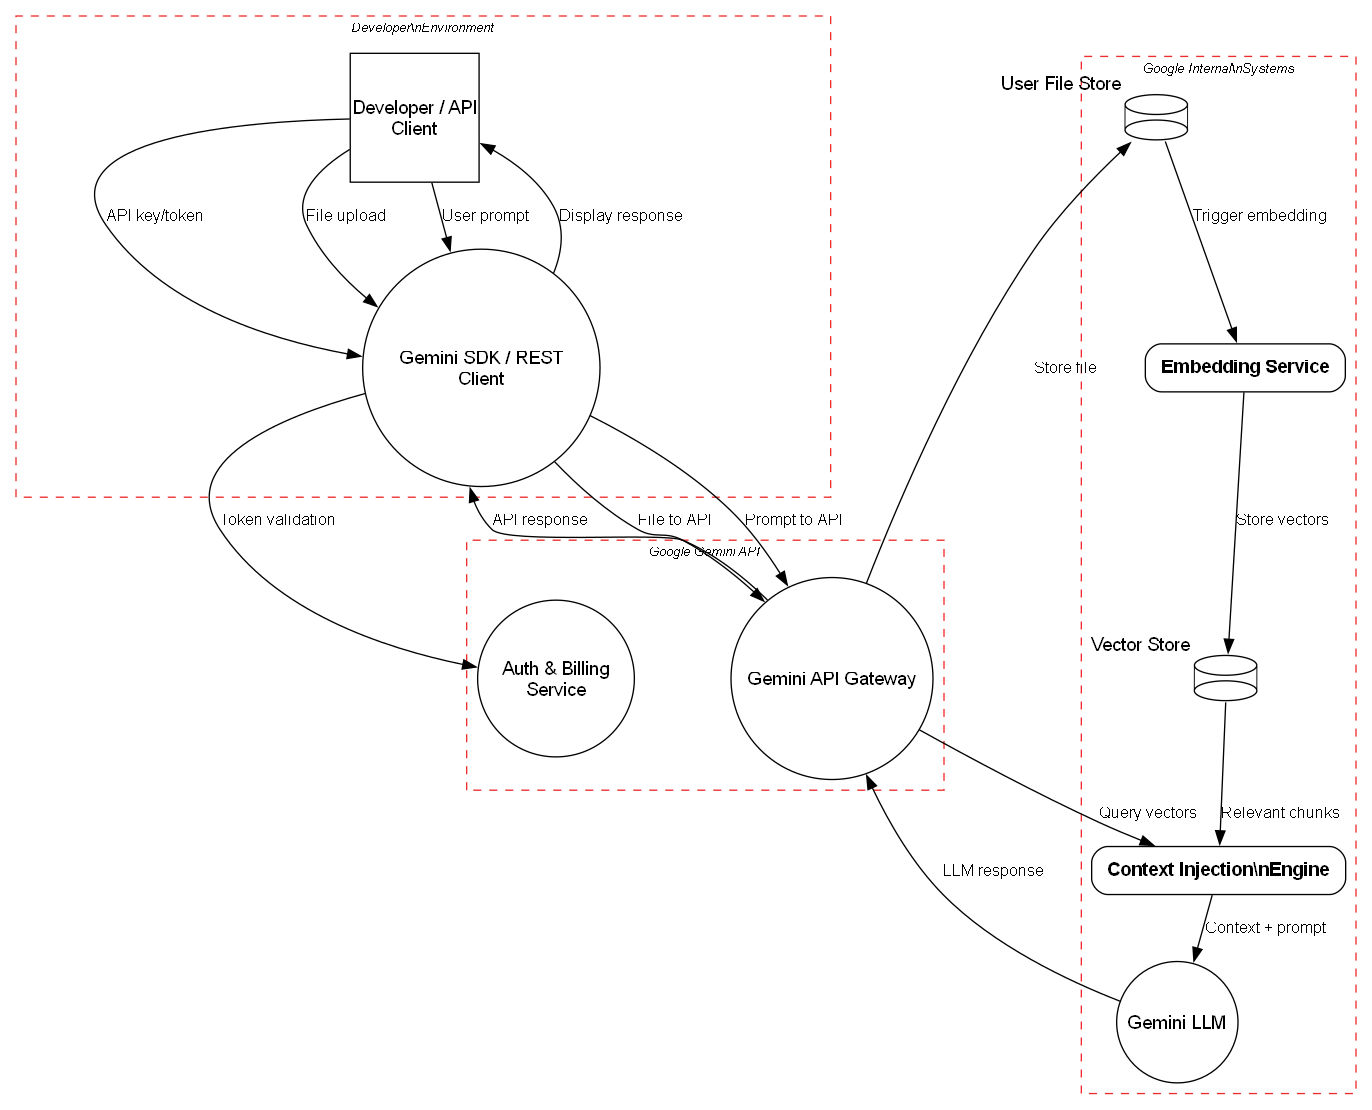

In [4]:
from IPython.display import Image, display
from graphviz import Source

dfd_dot = tm.dfd()
(OUT_DIR / "gemini_dfd.dot").write_text(dfd_dot, encoding="utf-8")

if HAS_DOT:
    src = Source(dfd_dot, directory=str(OUT_DIR), filename="gemini_dfd", format="png")
    png_path = src.render(cleanup=True)
    print(f"Wrote {png_path}")
    display(Image(png_path))
else:
    print(f"dot binary not found; saved DOT source only -> {OUT_DIR / 'gemini_dfd.dot'}")

## 4. Sequence diagram (PlantUML)

Saves `out/gemini_sequence.puml`. If Java + the PlantUML jar are available,
also renders `out/gemini_sequence.png`.

In [5]:
puml_path = OUT_DIR / "gemini_sequence.puml"
puml_path.write_text(tm.seq(), encoding="utf-8")
print(f"Wrote {puml_path}")

if HAS_JAVA and PLANTUML_JAR.exists():
    try:
        subprocess.run(
            ["java", "-jar", str(PLANTUML_JAR), "-tpng", str(puml_path), "-o", str(OUT_DIR)],
            check=True, capture_output=True,
        )
        seq_png = OUT_DIR / "gemini_sequence.png"
        if seq_png.exists():
            print(f"Wrote {seq_png}")
            display(Image(str(seq_png)))
    except subprocess.CalledProcessError as e:
        print(f"PlantUML render failed: {e.stderr.decode(errors='ignore')[:200]}")
else:
    print("Skipping PNG render (need Java + plantuml.jar). PUML source saved.")

Wrote C:\Users\CharlesCPhiri\source\repos\threatModelling\out\gemini_sequence.puml
Skipping PNG render (need Java + plantuml.jar). PUML source saved.


## 5. Generate the Markdown threat report

Renders `out/gemini_threat_report.md` from a Jinja2 template based on the
PyTM-evaluated threats.

In [6]:
from jinja2 import Template
from IPython.display import Markdown

template = Template("""# Threat Model Report: {{ tm.name }}

{{ tm.description }}

## Findings ({{ threats|length }})

{% for f in threats %}### {{ f.id }} — {{ f.description }}

- **Severity:** {{ f.severity }}
- **Target:** {{ f.target }}
- **Details:** {{ f.details }}
- **Mitigations:** {{ f.mitigations }}

{% endfor %}
""")

report_md = template.render(tm=tm, threats=tm._threats)
report_path = OUT_DIR / "gemini_threat_report.md"
report_path.write_text(report_md, encoding="utf-8")
print(f"Wrote {report_path}")

high   = sum(1 for t in tm._threats if str(getattr(t, "severity", "")).lower() == "high")
medium = sum(1 for t in tm._threats if str(getattr(t, "severity", "")).lower() == "medium")
low    = sum(1 for t in tm._threats if str(getattr(t, "severity", "")).lower() == "low")
print(f"Severity breakdown -- high: {high}, medium: {medium}, low: {low}")

display(Markdown(report_md))

Wrote C:\Users\CharlesCPhiri\source\repos\threatModelling\out\gemini_threat_report.md
Severity breakdown -- high: 43, medium: 37, low: 4


# Threat Model Report: Gemini File Search - Managed RAG API

Threat model for Gemini File Search RAG API

## Findings (103)

### INP01 — Buffer Overflow via Environment Variables

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Lambda'>, <class 'pytm.pytm.Process'>)
- **Details:** This attack pattern involves causing a buffer overflow through manipulation of environment variables. Once the attacker finds that they can modify an environment variable, they may try to overflow associated buffers. This attack leverages implicit trust often placed in environment variables.
- **Mitigations:** Do not expose environment variable to the user.Do not use untrusted data in your environment variables. Use a language or compiler that performs automatic bounds checking. There are tools such as Sharefuzz [R.10.3] which is an environment variable fuzzer for Unix that support loading a shared library. You can use Sharefuzz to determine if you are exposing an environment variable vulnerable to buffer overflow.

### INP02 — Overflow Buffers

- **Severity:** Very High
- **Target:** (<class 'pytm.pytm.Process'>,)
- **Details:** Buffer Overflow attacks target improper or missing bounds checking on buffer operations, typically triggered by input injected by an adversary. As a consequence, an adversary is able to write past the boundaries of allocated buffer regions in memory, causing a program crash or potentially redirection of execution as per the adversaries' choice.
- **Mitigations:** Use a language or compiler that performs automatic bounds checking. Use secure functions not vulnerable to buffer overflow. If you have to use dangerous functions, make sure that you do boundary checking. Compiler-based canary mechanisms such as StackGuard, ProPolice and the Microsoft Visual Studio /GS flag. Unless this provides automatic bounds checking, it is not a complete solution. Use OS-level preventative functionality. Not a complete solution. Utilize static source code analysis tools to identify potential buffer overflow weaknesses in the software.

### INP03 — Server Side Include (SSI) Injection

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An attacker can use Server Side Include (SSI) Injection to send code to a web application that then gets executed by the web server. Doing so enables the attacker to achieve similar results to Cross Site Scripting, viz., arbitrary code execution and information disclosure, albeit on a more limited scale, since the SSI directives are nowhere near as powerful as a full-fledged scripting language. Nonetheless, the attacker can conveniently gain access to sensitive files, such as password files, and execute shell commands.
- **Mitigations:** Set the OPTIONS IncludesNOEXEC in the global access.conf file or local .htaccess (Apache) file to deny SSI execution in directories that do not need them. All user controllable input must be appropriately sanitized before use in the application. This includes omitting, or encoding, certain characters or strings that have the potential of being interpreted as part of an SSI directive. Server Side Includes must be enabled only if there is a strong business reason to do so. Every additional component enabled on the web server increases the attack surface as well as administrative overhead.

### CR01 — Session Sidejacking

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Dataflow'>, <class 'pytm.pytm.Server'>)
- **Details:** Session sidejacking takes advantage of an unencrypted communication channel between a victim and target system. The attacker sniffs traffic on a network looking for session tokens in unencrypted traffic. Once a session token is captured, the attacker performs malicious actions by using the stolen token with the targeted application to impersonate the victim. This attack is a specific method of session hijacking, which is exploiting a valid session token to gain unauthorized access to a target system or information. Other methods to perform a session hijacking are session fixation, cross-site scripting, or compromising a user or server machine and stealing the session token.
- **Mitigations:** Make sure that HTTPS is used to communicate with the target system. Alternatively, use VPN if possible. It is important to ensure that all communication between the client and the server happens via an encrypted secure channel. Modify the session token with each transmission and protect it with cryptography. Add the idea of request sequencing that gives the server an ability to detect replay attacks.

### INP04 — HTTP Request Splitting

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** HTTP Request Splitting (also known as HTTP Request Smuggling) is an attack pattern where an attacker attempts to insert additional HTTP requests in the body of the original (enveloping) HTTP request in such a way that the browser interprets it as one request but the web server interprets it as two. There are several ways to perform HTTP request splitting attacks. One way is to include double Content-Length headers in the request to exploit the fact that the devices parsing the request may each use a different header. Another way is to submit an HTTP request with a Transfer Encoding: chunked in the request header set with setRequestHeader to allow a payload in the HTTP Request that can be considered as another HTTP Request by a subsequent parsing entity. A third way is to use the Double CR in an HTTP header technique. There are also a few less general techniques targeting specific parsing vulnerabilities in certain web servers.
- **Mitigations:** Make sure to install the latest vendor security patches available for the web server. If possible, make use of SSL. Install a web application firewall that has been secured against HTTP Request Splitting. Use web servers that employ a tight HTTP parsing process.

### CR02 — Cross Site Tracing

- **Severity:** Very High
- **Target:** (<class 'pytm.pytm.Dataflow'>, <class 'pytm.pytm.Server'>)
- **Details:** Cross Site Tracing (XST) enables an adversary to steal the victim's session cookie and possibly other authentication credentials transmitted in the header of the HTTP request when the victim's browser communicates to destination system's web server. The adversary first gets a malicious script to run in the victim's browser that induces the browser to initiate an HTTP TRACE request to the web server. If the destination web server allows HTTP TRACE requests, it will proceed to return a response to the victim's web browser that contains the original HTTP request in its body. The function of HTTP TRACE, as defined by the HTTP specification, is to echo the request that the web server receives from the client back to the client. Since the HTTP header of the original request had the victim's session cookie in it, that session cookie can now be picked off the HTTP TRACE response and sent to the adversary's malicious site. XST becomes relevant when direct access to the session cookie via the document.cookie object is disabled with the use of httpOnly attribute which ensures that the cookie can be transmitted in HTTP requests but cannot be accessed in other ways. Using SSL does not protect against XST. If the system with which the victim is interacting is susceptible to XSS, an adversary can exploit that weakness directly to get his or her malicious script to issue an HTTP TRACE request to the destination system's web server. In the absence of an XSS weakness on the site with which the victim is interacting, an adversary can get the script to come from the site that he controls and get it to execute in the victim's browser (if he can trick the victim's into visiting his malicious website or clicking on the link that he supplies). However, in that case, due to the same origin policy protection mechanism in the browser, the adversary's malicious script cannot directly issue an HTTP TRACE request to the destination system's web server because the malicious script did not originate at that domain. An adversary will then need to find a way to exploit another weakness that would enable him or her to get around the same origin policy protection.
- **Mitigations:** Administrators should disable support for HTTP TRACE at the destination's web server. Vendors should disable TRACE by default. Patch web browser against known security origin policy bypass exploits.

### INP05 — Command Line Execution through SQL Injection

- **Severity:** Very High
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An attacker uses standard SQL injection methods to inject data into the command line for execution. This could be done directly through misuse of directives such as MSSQL_xp_cmdshell or indirectly through injection of data into the database that would be interpreted as shell commands. Sometime later, an unscrupulous backend application (or could be part of the functionality of the same application) fetches the injected data stored in the database and uses this data as command line arguments without performing proper validation. The malicious data escapes that data plane by spawning new commands to be executed on the host.
- **Mitigations:** Disable MSSQL xp_cmdshell directive on the databaseProperly validate the data (syntactically and semantically) before writing it to the database. Do not implicitly trust the data stored in the database. Re-validate it prior to usage to make sure that it is safe to use in a given context (e.g. as a command line argument).

### INP06 — SQL Injection through SOAP Parameter Tampering

- **Severity:** Very High
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An attacker modifies the parameters of the SOAP message that is sent from the service consumer to the service provider to initiate a SQL injection attack. On the service provider side, the SOAP message is parsed and parameters are not properly validated before being used to access a database in a way that does not use parameter binding, thus enabling the attacker to control the structure of the executed SQL query. This pattern describes a SQL injection attack with the delivery mechanism being a SOAP message.
- **Mitigations:** Properly validate and sanitize/reject user input at the service provider. Ensure that prepared statements or other mechanism that enables parameter binding is used when accessing the database in a way that would prevent the attackers' supplied data from controlling the structure of the executed query. At the database level, ensure that the database user used by the application in a particular context has the minimum needed privileges to the database that are needed to perform the operation. When possible, run queries against pre-generated views rather than the tables directly.

### SC01 — JSON Hijacking (aka JavaScript Hijacking)

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Process'>,)
- **Details:** An attacker targets a system that uses JavaScript Object Notation (JSON) as a transport mechanism between the client and the server (common in Web 2.0 systems using AJAX) to steal possibly confidential information transmitted from the server back to the client inside the JSON object by taking advantage of the loophole in the browser's Same Origin Policy that does not prohibit JavaScript from one website to be included and executed in the context of another website. An attacker gets the victim to visit his or her malicious page that contains a script tag whose source points to the vulnerable system with a URL that requests a response from the server containing a JSON object with possibly confidential information. The malicious page also contains malicious code to capture the JSON object returned by the server before any other processing on it can take place, typically by overriding the JavaScript function used to create new objects. This hook allows the malicious code to get access to the creation of each object and transmit the possibly sensitive contents of the captured JSON object to the attackers' server. There is nothing in the browser's security model to prevent the attackers' malicious JavaScript code (originating from attacker's domain) to set up an environment (as described above) to intercept a JSON object response (coming from the vulnerable target system's domain), read its contents and transmit to the attackers' controlled site. The same origin policy protects the domain object model (DOM), but not the JSON.
- **Mitigations:** Ensure that server side code can differentiate between legitimate requests and forged requests. The solution is similar to protection against Cross Site Request Forger (CSRF), which is to use a hard to guess random nonce (that is unique to the victim's session with the server) that the attacker has no way of knowing (at least in the absence of other weaknesses). Each request from the client to the server should contain this nonce and the server should reject all requests that do not contain the nonce. On the client side, the system's design could make it difficult to get access to the JSON object content via the script tag. Since the JSON object is never assigned locally to a variable, it cannot be readily modified by the attacker before being used by a script tag. For instance, if while(1) was added to the beginning of the JavaScript returned by the server, trying to access it with a script tag would result in an infinite loop. On the other hand, legitimate client side code can remove the while(1) statement after which the JavaScript can be evaluated. A similar result can be achieved by surrounding the returned JavaScript with comment tags, or using other similar techniques (e.g. wrapping the JavaScript with HTML tags). Make the URLs in the system used to retrieve JSON objects unpredictable and unique for each user session. 4. Ensure that to the extent possible, no sensitive data is passed from the server to the client via JSON objects. JavaScript was never intended to play that role, hence the same origin policy does not adequate address this scenario.

### LB01 — API Manipulation

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Process'>, <class 'pytm.pytm.Lambda'>)
- **Details:** An adversary manipulates the use or processing of an Application Programming Interface (API) resulting in an adverse impact upon the security of the system implementing the API. This can allow the adversary to execute functionality not intended by the API implementation, possibly compromising the system which integrates the API. API manipulation can take on a number of forms including forcing the unexpected use of an API, or the use of an API in an unintended way. For example, an adversary may make a request to an application that leverages a non-standard API that is known to incorrectly validate its data and thus it may be manipulated by supplying metacharacters or alternate encodings as input, resulting in any number of injection flaws, including SQL injection, cross-site scripting, or command execution. Another example could be API methods that should be disabled in a production application but were not, thus exposing dangerous functionality within a production environment.
- **Mitigations:** Always use HTTPS and SSL Certificates. Firewall optimizations to prevent unauthorized access to or from a private network. Use strong authentication and authorization mechanisms. A proven protocol is OAuth 2.0, which enables a third-party application to obtain limited access to an API. Use IP whitelisting and rate limiting.

### AA01 — Authentication Abuse/ByPass

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Server'>, <class 'pytm.pytm.Process'>)
- **Details:** An attacker obtains unauthorized access to an application, service or device either through knowledge of the inherent weaknesses of an authentication mechanism, or by exploiting a flaw in the authentication scheme's implementation. In such an attack an authentication mechanism is functioning but a carefully controlled sequence of events causes the mechanism to grant access to the attacker. This attack may exploit assumptions made by the target's authentication procedures, such as assumptions regarding trust relationships or assumptions regarding the generation of secret values. This attack differs from Authentication Bypass attacks in that Authentication Abuse allows the attacker to be certified as a valid user through illegitimate means, while Authentication Bypass allows the user to access protected material without ever being certified as an authenticated user. This attack does not rely on prior sessions established by successfully authenticating users, as relied upon for the Exploitation of Session Variables, Resource IDs and other Trusted Credentials attack patterns.
- **Mitigations:** Use strong authentication and authorization mechanisms. A proven protocol is OAuth 2.0, which enables a third-party application to obtain limited access to an API.

### DS01 — Excavation

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An adversary actively probes the target in a manner that is designed to solicit information that could be leveraged for malicious purposes. This is achieved by exploring the target via ordinary interactions for the purpose of gathering intelligence about the target, or by sending data that is syntactically invalid or non-standard in an attempt to produce a response that contains the desired data. As a result of these interactions, the adversary is able to obtain information from the target that aids the attacker in making inferences about its security, configuration, or potential vulnerabilities. Examplar exchanges with the target may trigger unhandled exceptions or verbose error messages that reveal information like stack traces, configuration information, path information, or database design. This type of attack also includes the manipulation of query strings in a URI to produce invalid SQL queries, or by trying alternative path values in the hope that the server will return useful information.
- **Mitigations:** Minimize error/response output to only what is necessary for functional use or corrective language. Remove potentially sensitive information that is not necessary for the application's functionality.

### DE01 — Interception

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Dataflow'>,)
- **Details:** An adversary monitors data streams to or from the target for information gathering purposes. This attack may be undertaken to solely gather sensitive information or to support a further attack against the target. This attack pattern can involve sniffing network traffic as well as other types of data streams (e.g. radio). The adversary can attempt to initiate the establishment of a data stream, influence the nature of the data transmitted, or passively observe the communications as they unfold. In all variants of this attack, the adversary is not the intended recipient of the data stream. In contrast to other means of gathering information (e.g., targeting data leaks), the adversary must actively position himself so as to observe explicit data channels (e.g. network traffic) and read the content.
- **Mitigations:** Leverage encryption to encode the transmission of data thus making it accessible only to authorized parties.

### DE02 — Double Encoding

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Server'>, <class 'pytm.pytm.Process'>)
- **Details:** The adversary utilizes a repeating of the encoding process for a set of characters (that is, character encoding a character encoding of a character) to obfuscate the payload of a particular request. This may allow the adversary to bypass filters that attempt to detect illegal characters or strings, such as those that might be used in traversal or injection attacks. Filters may be able to catch illegal encoded strings, but may not catch doubly encoded strings. For example, a dot (.), often used in path traversal attacks and therefore often blocked by filters, could be URL encoded as %2E. However, many filters recognize this encoding and would still block the request. In a double encoding, the % in the above URL encoding would be encoded again as %25, resulting in %252E which some filters might not catch, but which could still be interpreted as a dot (.) by interpreters on the target.
- **Mitigations:** Assume all input is malicious. Create a white list that defines all valid input to the software system based on the requirements specifications. Input that does not match against the white list should not be permitted to enter into the system. Test your decoding process against malicious input. Be aware of the threat of alternative method of data encoding and obfuscation technique such as IP address encoding. When client input is required from web-based forms, avoid using the GET method to submit data, as the method causes the form data to be appended to the URL and is easily manipulated. Instead, use the POST method whenever possible. Any security checks should occur after the data has been decoded and validated as correct data format. Do not repeat decoding process, if bad character are left after decoding process, treat the data as suspicious, and fail the validation process.Refer to the RFCs to safely decode URL. Regular expression can be used to match safe URL patterns. However, that may discard valid URL requests if the regular expression is too restrictive. There are tools to scan HTTP requests to the server for valid URL such as URLScan from Microsoft (http://www.microsoft.com/technet/security/tools/urlscan.mspx).

### API01 — Exploit Test APIs

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Process'>, <class 'pytm.pytm.Lambda'>)
- **Details:** An attacker exploits a sample, demonstration, or test API that is insecure by default and should not be resident on production systems. Some applications include APIs that are intended to allow an administrator to test and refine their domain. These APIs should usually be disabled once a system enters a production environment. Testing APIs may expose a great deal of diagnostic information intended to aid an administrator, but which can also be used by an attacker to further refine their attack. Moreover, testing APIs may not have adequate security controls or may not have undergone rigorous testing since they were not intended for use in production environments. As such, they may have many flaws and vulnerabilities that would allow an attacker to severely disrupt a target.
- **Mitigations:** Ensure that production systems to not contain sample or test APIs and that these APIs are only used in development environments.

### AC01 — Privilege Abuse

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Server'>, <class 'pytm.pytm.Process'>, <class 'pytm.pytm.Datastore'>)
- **Details:** An adversary is able to exploit features of the target that should be reserved for privileged users or administrators but are exposed to use by lower or non-privileged accounts. Access to sensitive information and functionality must be controlled to ensure that only authorized users are able to access these resources. If access control mechanisms are absent or misconfigured, a user may be able to access resources that are intended only for higher level users. An adversary may be able to exploit this to utilize a less trusted account to gain information and perform activities reserved for more trusted accounts. This attack differs from privilege escalation and other privilege stealing attacks in that the adversary never actually escalates their privileges but instead is able to use a lesser degree of privilege to access resources that should be (but are not) reserved for higher privilege accounts. Likewise, the adversary does not exploit trust or subvert systems - all control functionality is working as configured but the configuration does not adequately protect sensitive resources at an appropriate level.
- **Mitigations:** Use strong authentication and authorization mechanisms. A proven protocol is OAuth 2.0, which enables a third-party application to obtain limited access to an API.

### INP07 — Buffer Manipulation

- **Severity:** Very High
- **Target:** (<class 'pytm.pytm.Process'>,)
- **Details:** An adversary manipulates an application's interaction with a buffer in an attempt to read or modify data they shouldn't have access to. Buffer attacks are distinguished in that it is the buffer space itself that is the target of the attack rather than any code responsible for interpreting the content of the buffer. In virtually all buffer attacks the content that is placed in the buffer is immaterial. Instead, most buffer attacks involve retrieving or providing more input than can be stored in the allocated buffer, resulting in the reading or overwriting of other unintended program memory.
- **Mitigations:** To help protect an application from buffer manipulation attacks, a number of potential mitigations can be leveraged. Before starting the development of the application, consider using a code language (e.g., Java) or compiler that limits the ability of developers to act beyond the bounds of a buffer. If the chosen language is susceptible to buffer related issues (e.g., C) then consider using secure functions instead of those vulnerable to buffer manipulations. If a potentially dangerous function must be used, make sure that proper boundary checking is performed. Additionally, there are often a number of compiler-based mechanisms (e.g., StackGuard, ProPolice and the Microsoft Visual Studio /GS flag) that can help identify and protect against potential buffer issues. Finally, there may be operating system level preventative functionality that can be applied.

### AC02 — Shared Data Manipulation

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Datastore'>,)
- **Details:** An adversary exploits a data structure shared between multiple applications or an application pool to affect application behavior. Data may be shared between multiple applications or between multiple threads of a single application. Data sharing is usually accomplished through mutual access to a single memory location. If an adversary can manipulate this shared data (usually by co-opting one of the applications or threads) the other applications or threads using the shared data will often continue to trust the validity of the compromised shared data and use it in their calculations. This can result in invalid trust assumptions, corruption of additional data through the normal operations of the other users of the shared data, or even cause a crash or compromise of the sharing applications.
- **Mitigations:** Use strong authentication and authorization mechanisms. Use HTTPS/SSL for communication.

### DO01 — Flooding

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Process'>, <class 'pytm.pytm.Server'>)
- **Details:** An adversary consumes the resources of a target by rapidly engaging in a large number of interactions with the target. This type of attack generally exposes a weakness in rate limiting or flow. When successful this attack prevents legitimate users from accessing the service and can cause the target to crash. This attack differs from resource depletion through leaks or allocations in that the latter attacks do not rely on the volume of requests made to the target but instead focus on manipulation of the target's operations. The key factor in a flooding attack is the number of requests the adversary can make in a given period of time. The greater this number, the more likely an attack is to succeed against a given target.
- **Mitigations:** Ensure that protocols have specific limits of scale configured. Specify expectations for capabilities and dictate which behaviors are acceptable when resource allocation reaches limits. Uniformly throttle all requests in order to make it more difficult to consume resources more quickly than they can again be freed.

### HA01 — Path Traversal

- **Severity:** Very High
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An adversary uses path manipulation methods to exploit insufficient input validation of a target to obtain access to data that should be not be retrievable by ordinary well-formed requests. A typical variety of this attack involves specifying a path to a desired file together with dot-dot-slash characters, resulting in the file access API or function traversing out of the intended directory structure and into the root file system. By replacing or modifying the expected path information the access function or API retrieves the file desired by the attacker. These attacks either involve the attacker providing a complete path to a targeted file or using control characters (e.g. path separators (/ or ) and/or dots (.)) to reach desired directories or files.
- **Mitigations:** Design: Configure the access control correctly. Design: Enforce principle of least privilege. Design: Execute programs with constrained privileges, so parent process does not open up further vulnerabilities. Ensure that all directories, temporary directories and files, and memory are executing with limited privileges to protect against remote execution. Design: Input validation. Assume that user inputs are malicious. Utilize strict type, character, and encoding enforcement. Design: Proxy communication to host, so that communications are terminated at the proxy, sanitizing the requests before forwarding to server host. 6. Design: Run server interfaces with a non-root account and/or utilize chroot jails or other configuration techniques to constrain privileges even if attacker gains some limited access to commands. Implementation: Host integrity monitoring for critical files, directories, and processes. The goal of host integrity monitoring is to be aware when a security issue has occurred so that incident response and other forensic activities can begin. Implementation: Perform input validation for all remote content, including remote and user-generated content. Implementation: Perform testing such as pen-testing and vulnerability scanning to identify directories, programs, and interfaces that grant direct access to executables. Implementation: Use indirect references rather than actual file names. Implementation: Use possible permissions on file access when developing and deploying web applications. Implementation: Validate user input by only accepting known good. Ensure all content that is delivered to client is sanitized against an acceptable content specification -- whitelisting approach.

### AC03 — Subverting Environment Variable Values

- **Severity:** Very High
- **Target:** (<class 'pytm.pytm.Process'>, <class 'pytm.pytm.Lambda'>)
- **Details:** The attacker directly or indirectly modifies environment variables used by or controlling the target software. The attacker's goal is to cause the target software to deviate from its expected operation in a manner that benefits the attacker.
- **Mitigations:** Protect environment variables against unauthorized read and write access. Protect the configuration files which contain environment variables against illegitimate read and write access. Assume all input is malicious. Create a white list that defines all valid input to the software system based on the requirements specifications. Input that does not match against the white list should not be permitted to enter into the system. Apply the least privilege principles. If a process has no legitimate reason to read an environment variable do not give that privilege.

### DO02 — Excessive Allocation

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Process'>, <class 'pytm.pytm.Server'>, <class 'pytm.pytm.Datastore'>, <class 'pytm.pytm.Lambda'>)
- **Details:** An adversary causes the target to allocate excessive resources to servicing the attackers' request, thereby reducing the resources available for legitimate services and degrading or denying services. Usually, this attack focuses on memory allocation, but any finite resource on the target could be the attacked, including bandwidth, processing cycles, or other resources. This attack does not attempt to force this allocation through a large number of requests (that would be Resource Depletion through Flooding) but instead uses one or a small number of requests that are carefully formatted to force the target to allocate excessive resources to service this request(s). Often this attack takes advantage of a bug in the target to cause the target to allocate resources vastly beyond what would be needed for a normal request.
- **Mitigations:** Limit the amount of resources that are accessible to unprivileged users. Assume all input is malicious. Consider all potentially relevant properties when validating input. Consider uniformly throttling all requests in order to make it more difficult to consume resources more quickly than they can again be freed. Use resource-limiting settings, if possible.

### DS02 — Try All Common Switches

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Lambda'>, <class 'pytm.pytm.Process'>)
- **Details:** An attacker attempts to invoke all common switches and options in the target application for the purpose of discovering weaknesses in the target. For example, in some applications, adding a --debug switch causes debugging information to be displayed, which can sometimes reveal sensitive processing or configuration information to an attacker. This attack differs from other forms of API abuse in that the attacker is blindly attempting to invoke options in the hope that one of them will work rather than specifically targeting a known option. Nonetheless, even if the attacker is familiar with the published options of a targeted application this attack method may still be fruitful as it might discover unpublicized functionality.
- **Mitigations:** Design: Minimize switch and option functionality to only that necessary for correct function of the command. Implementation: Remove all debug and testing options from production code.

### INP08 — Format String Injection

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Lambda'>, <class 'pytm.pytm.Process'>, <class 'pytm.pytm.Server'>)
- **Details:** An adversary includes formatting characters in a string input field on the target application. Most applications assume that users will provide static text and may respond unpredictably to the presence of formatting character. For example, in certain functions of the C programming languages such as printf, the formatting character %s will print the contents of a memory location expecting this location to identify a string and the formatting character %n prints the number of DWORD written in the memory. An adversary can use this to read or write to memory locations or files, or simply to manipulate the value of the resulting text in unexpected ways. Reading or writing memory may result in program crashes and writing memory could result in the execution of arbitrary code if the adversary can write to the program stack.
- **Mitigations:** Limit the usage of formatting string functions. Strong input validation - All user-controllable input must be validated and filtered for illegal formatting characters.

### INP09 — LDAP Injection

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An attacker manipulates or crafts an LDAP query for the purpose of undermining the security of the target. Some applications use user input to create LDAP queries that are processed by an LDAP server. For example, a user might provide their username during authentication and the username might be inserted in an LDAP query during the authentication process. An attacker could use this input to inject additional commands into an LDAP query that could disclose sensitive information. For example, entering a * in the aforementioned query might return information about all users on the system. This attack is very similar to an SQL injection attack in that it manipulates a query to gather additional information or coerce a particular return value.
- **Mitigations:** Strong input validation - All user-controllable input must be validated and filtered for illegal characters as well as LDAP content. Use of custom error pages - Attackers can glean information about the nature of queries from descriptive error messages. Input validation must be coupled with customized error pages that inform about an error without disclosing information about the LDAP or application.

### INP10 — Parameter Injection

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An adversary manipulates the content of request parameters for the purpose of undermining the security of the target. Some parameter encodings use text characters as separators. For example, parameters in a HTTP GET message are encoded as name-value pairs separated by an ampersand (&). If an attacker can supply text strings that are used to fill in these parameters, then they can inject special characters used in the encoding scheme to add or modify parameters. For example, if user input is fed directly into an HTTP GET request and the user provides the value myInput&new_param=myValue, then the input parameter is set to myInput, but a new parameter (new_param) is also added with a value of myValue. This can significantly change the meaning of the query that is processed by the server. Any encoding scheme where parameters are identified and separated by text characters is potentially vulnerable to this attack - the HTTP GET encoding used above is just one example.
- **Mitigations:** Implement an audit log written to a separate host. In the event of a compromise, the audit log may be able to provide evidence and details of the compromise. Treat all user input as untrusted data that must be validated before use.

### INP11 — Relative Path Traversal

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An attacker exploits a weakness in input validation on the target by supplying a specially constructed path utilizing dot and slash characters for the purpose of obtaining access to arbitrary files or resources. An attacker modifies a known path on the target in order to reach material that is not available through intended channels. These attacks normally involve adding additional path separators (/ or ) and/or dots (.), or encodings thereof, in various combinations in order to reach parent directories or entirely separate trees of the target's directory structure.
- **Mitigations:** Design: Input validation. Assume that user inputs are malicious. Utilize strict type, character, and encoding enforcement. Implementation: Perform input validation for all remote content, including remote and user-generated content. Implementation: Validate user input by only accepting known good. Ensure all content that is delivered to client is sanitized against an acceptable content specification -- whitelisting approach. Implementation: Prefer working without user input when using file system calls. Implementation: Use indirect references rather than actual file names. Implementation: Use possible permissions on file access when developing and deploying web applications.

### INP12 — Client-side Injection-induced Buffer Overflow

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Lambda'>, <class 'pytm.pytm.Process'>)
- **Details:** This type of attack exploits a buffer overflow vulnerability in targeted client software through injection of malicious content from a custom-built hostile service.
- **Mitigations:** The client software should not install untrusted code from a non-authenticated server. The client software should have the latest patches and should be audited for vulnerabilities before being used to communicate with potentially hostile servers. Perform input validation for length of buffer inputs. Use a language or compiler that performs automatic bounds checking. Use an abstraction library to abstract away risky APIs. Not a complete solution. Compiler-based canary mechanisms such as StackGuard, ProPolice and the Microsoft Visual Studio /GS flag. Unless this provides automatic bounds checking, it is not a complete solution. Ensure all buffer uses are consistently bounds-checked. Use OS-level preventative functionality. Not a complete solution.

### AC04 — XML Schema Poisoning

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Dataflow'>,)
- **Details:** An adversary corrupts or modifies the content of XML schema information passed between a client and server for the purpose of undermining the security of the target. XML Schemas provide the structure and content definitions for XML documents. Schema poisoning is the ability to manipulate a schema either by replacing or modifying it to compromise the programs that process documents that use this schema. Possible attacks are denial of service attacks by modifying the schema so that it does not contain required information for subsequent processing. For example, the unaltered schema may require a @name attribute in all submitted documents. If the adversary removes this attribute from the schema then documents created using the new grammar may lack this field, which may cause the processing application to enter an unexpected state or record incomplete data. In addition, manipulation of the data types described in the schema may affect the results of calculations taken by the document reader. For example, a float field could be changed to an int field. Finally, the adversary may change the encoding defined in the schema for certain fields allowing the contents to bypass filters that scan for dangerous strings. For example, the modified schema might us a URL encoding instead of ASCII, and a filter that catches a semicolon (;) might fail to detect its URL encoding (%3B).
- **Mitigations:** Design: Protect the schema against unauthorized modification. Implementation: For applications that use a known schema, use a local copy or a known good repository instead of the schema reference supplied in the XML document. Additionally, ensure that the proper permissions are set on local files to avoid unauthorized modification. Implementation: For applications that leverage remote schemas, use the HTTPS protocol to prevent modification of traffic in transit and to avoid unauthorized modification.

### DO03 — XML Ping of the Death

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Dataflow'>,)
- **Details:** An attacker initiates a resource depletion attack where a large number of small XML messages are delivered at a sufficiently rapid rate to cause a denial of service or crash of the target. Transactions such as repetitive SOAP transactions can deplete resources faster than a simple flooding attack because of the additional resources used by the SOAP protocol and the resources necessary to process SOAP messages. The transactions used are immaterial as long as they cause resource utilization on the target. In other words, this is a normal flooding attack augmented by using messages that will require extra processing on the target.
- **Mitigations:** Design: Build throttling mechanism into the resource allocation. Provide for a timeout mechanism for allocated resources whose transaction does not complete within a specified interval. Implementation: Provide for network flow control and traffic shaping to control access to the resources.

### AC05 — Content Spoofing

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Dataflow'>,)
- **Details:** An adversary modifies content to make it contain something other than what the original content producer intended while keeping the apparent source of the content unchanged. The term content spoofing is most often used to describe modification of web pages hosted by a target to display the adversary's content instead of the owner's content. However, any content can be spoofed, including the content of email messages, file transfers, or the content of other network communication protocols. Content can be modified at the source (e.g. modifying the source file for a web page) or in transit (e.g. intercepting and modifying a message between the sender and recipient). Usually, the adversary will attempt to hide the fact that the content has been modified, but in some cases, such as with web site defacement, this is not necessary. Content Spoofing can lead to malware exposure, financial fraud (if the content governs financial transactions), privacy violations, and other unwanted outcomes.
- **Mitigations:** Validation of user input for type, length, data-range, format, etc. Encoding any user input that will be output by the web application.

### INP13 — Command Delimiters

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Lambda'>, <class 'pytm.pytm.Process'>)
- **Details:** An attack of this type exploits a programs' vulnerabilities that allows an attacker's commands to be concatenated onto a legitimate command with the intent of targeting other resources such as the file system or database. The system that uses a filter or a blacklist input validation, as opposed to whitelist validation is vulnerable to an attacker who predicts delimiters (or combinations of delimiters) not present in the filter or blacklist. As with other injection attacks, the attacker uses the command delimiter payload as an entry point to tunnel through the application and activate additional attacks through SQL queries, shell commands, network scanning, and so on.
- **Mitigations:** Design: Perform whitelist validation against a positive specification for command length, type, and parameters.Design: Limit program privileges, so if commands circumvent program input validation or filter routines then commands do not running under a privileged accountImplementation: Perform input validation for all remote content.Implementation: Use type conversions such as JDBC prepared statements.

### INP14 — Input Data Manipulation

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Process'>, <class 'pytm.pytm.Lambda'>, <class 'pytm.pytm.Server'>)
- **Details:** An attacker exploits a weakness in input validation by controlling the format, structure, and composition of data to an input-processing interface. By supplying input of a non-standard or unexpected form an attacker can adversely impact the security of the target. For example, using a different character encoding might cause dangerous text to be treated as safe text. Alternatively, the attacker may use certain flags, such as file extensions, to make a target application believe that provided data should be handled using a certain interpreter when the data is not actually of the appropriate type. This can lead to bypassing protection mechanisms, forcing the target to use specific components for input processing, or otherwise causing the user's data to be handled differently than might otherwise be expected. This attack differs from Variable Manipulation in that Variable Manipulation attempts to subvert the target's processing through the value of the input while Input Data Manipulation seeks to control how the input is processed.
- **Mitigations:** Validation of user input for type, length, data-range, format, etc.

### DE03 — Sniffing Attacks

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Dataflow'>,)
- **Details:** In this attack pattern, the adversary intercepts information transmitted between two third parties. The adversary must be able to observe, read, and/or hear the communication traffic, but not necessarily block the communication or change its content. The adversary may precipitate or indirectly influence the content of the observed transaction, but is never the intended recipient of the information. Any transmission medium can theoretically be sniffed if the adversary can examine the contents between the sender and recipient.
- **Mitigations:** Encrypt sensitive information when transmitted on insecure mediums to prevent interception.

### CR03 — Dictionary-based Password Attack

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Process'>, <class 'pytm.pytm.Server'>)
- **Details:** An attacker tries each of the words in a dictionary as passwords to gain access to the system via some user's account. If the password chosen by the user was a word within the dictionary, this attack will be successful (in the absence of other mitigations). This is a specific instance of the password brute forcing attack pattern.
- **Mitigations:** Create a strong password policy and ensure that your system enforces this policy.Implement an intelligent password throttling mechanism. Care must be taken to assure that these mechanisms do not excessively enable account lockout attacks such as CAPEC-02.

### API02 — Exploit Script-Based APIs

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Process'>, <class 'pytm.pytm.Lambda'>)
- **Details:** Some APIs support scripting instructions as arguments. Methods that take scripted instructions (or references to scripted instructions) can be very flexible and powerful. However, if an attacker can specify the script that serves as input to these methods they can gain access to a great deal of functionality. For example, HTML pages support <script> tags that allow scripting languages to be embedded in the page and then interpreted by the receiving web browser. If the content provider is malicious, these scripts can compromise the client application. Some applications may even execute the scripts under their own identity (rather than the identity of the user providing the script) which can allow attackers to perform activities that would otherwise be denied to them.
- **Mitigations:** Always use HTTPS and SSL Certificates. Firewall optimizations to prevent unauthorized access to or from a private network. Use strong authentication and authorization mechanisms. A proven protocol is OAuth 2.0, which enables a third-party application to obtain limited access to an API. Use IP whitelisting and rate limiting.

### HA02 — White Box Reverse Engineering

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.ExternalEntity'>,)
- **Details:** An attacker discovers the structure, function, and composition of a type of computer software through white box analysis techniques. White box techniques involve methods which can be applied to a piece of software when an executable or some other compiled object can be directly subjected to analysis, revealing at least a portion of its machine instructions that can be observed upon execution.
- **Mitigations:** Employ code obfuscation techniques to prevent the adversary from reverse engineering the targeted entity.

### DS03 — Footprinting

- **Severity:** Very Low
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An adversary engages in probing and exploration activities to identify constituents and properties of the target. Footprinting is a general term to describe a variety of information gathering techniques, often used by attackers in preparation for some attack. It consists of using tools to learn as much as possible about the composition, configuration, and security mechanisms of the targeted application, system or network. Information that might be collected during a footprinting effort could include open ports, applications and their versions, network topology, and similar information. While footprinting is not intended to be damaging (although certain activities, such as network scans, can sometimes cause disruptions to vulnerable applications inadvertently) it may often pave the way for more damaging attacks.
- **Mitigations:** Keep patches up to date by installing weekly or daily if possible.Shut down unnecessary services/ports.Change default passwords by choosing strong passwords.Curtail unexpected input.Encrypt and password-protect sensitive data.Avoid including information that has the potential to identify and compromise your organization's security such as access to business plans, formulas, and proprietary documents.

### AC06 — Using Malicious Files

- **Severity:** Very High
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An attack of this type exploits a system's configuration that allows an attacker to either directly access an executable file, for example through shell access; or in a possible worst case allows an attacker to upload a file and then execute it. Web servers, ftp servers, and message oriented middleware systems which have many integration points are particularly vulnerable, because both the programmers and the administrators must be in synch regarding the interfaces and the correct privileges for each interface.
- **Mitigations:** Design: Enforce principle of least privilegeDesign: Run server interfaces with a non-root account and/or utilize chroot jails or other configuration techniques to constrain privileges even if attacker gains some limited access to commands.Implementation: Perform testing such as pen-testing and vulnerability scanning to identify directories, programs, and interfaces that grant direct access to executables.

### HA03 — Web Application Fingerprinting

- **Severity:** Low
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An attacker sends a series of probes to a web application in order to elicit version-dependent and type-dependent behavior that assists in identifying the target. An attacker could learn information such as software versions, error pages, and response headers, variations in implementations of the HTTP protocol, directory structures, and other similar information about the targeted service. This information can then be used by an attacker to formulate a targeted attack plan. While web application fingerprinting is not intended to be damaging (although certain activities, such as network scans, can sometimes cause disruptions to vulnerable applications inadvertently) it may often pave the way for more damaging attacks.
- **Mitigations:** Implementation: Obfuscate server fields of HTTP response.Implementation: Hide inner ordering of HTTP response header.Implementation: Customizing HTTP error codes such as 404 or 500.Implementation: Hide URL file extension.Implementation: Hide HTTP response header software information filed.Implementation: Hide cookie's software information filed.Implementation: Appropriately deal with error messages.Implementation: Obfuscate database type in Database API's error message.

### SC02 — XSS Targeting Non-Script Elements

- **Severity:** Very High
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** This attack is a form of Cross-Site Scripting (XSS) where malicious scripts are embedded in elements that are not expected to host scripts such as image tags (<img>), comments in XML documents (< !-CDATA->), etc. These tags may not be subject to the same input validation, output validation, and other content filtering and checking routines, so this can create an opportunity for an attacker to tunnel through the application's elements and launch a XSS attack through other elements. As with all remote attacks, it is important to differentiate the ability to launch an attack (such as probing an internal network for unpatched servers) and the ability of the remote attacker to collect and interpret the output of said attack.
- **Mitigations:** In addition to the traditional input fields, all other user controllable inputs, such as image tags within messages or the likes, must also be subjected to input validation. Such validation should ensure that content that can be potentially interpreted as script by the browser is appropriately filtered.All output displayed to clients must be properly escaped. Escaping ensures that the browser interprets special scripting characters literally and not as script to be executed.

### AC07 — Exploiting Incorrectly Configured Access Control Security Levels

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An attacker exploits a weakness in the configuration of access controls and is able to bypass the intended protection that these measures guard against and thereby obtain unauthorized access to the system or network. Sensitive functionality should always be protected with access controls. However configuring all but the most trivial access control systems can be very complicated and there are many opportunities for mistakes. If an attacker can learn of incorrectly configured access security settings, they may be able to exploit this in an attack. Most commonly, attackers would take advantage of controls that provided too little protection for sensitive activities in order to perform actions that should be denied to them. In some circumstances, an attacker may be able to take advantage of overly restrictive access control policies, initiating denial of services (if an application locks because it unexpectedly failed to be granted access) or causing other legitimate actions to fail due to security. The latter class of attacks, however, is usually less severe and easier to detect than attacks based on inadequate security restrictions. This attack pattern differs from CAPEC 1, Accessing Functionality Not Properly Constrained by ACLs in that the latter describes attacks where sensitive functionality lacks access controls, where, in this pattern, the access control is present, but incorrectly configured.
- **Mitigations:** Design: Configure the access control correctly.

### INP15 — IMAP/SMTP Command Injection

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An attacker exploits weaknesses in input validation on IMAP/SMTP servers to execute commands on the server. Web-mail servers often sit between the Internet and the IMAP or SMTP mail server. User requests are received by the web-mail servers which then query the back-end mail server for the requested information and return this response to the user. In an IMAP/SMTP command injection attack, mail-server commands are embedded in parts of the request sent to the web-mail server. If the web-mail server fails to adequately sanitize these requests, these commands are then sent to the back-end mail server when it is queried by the web-mail server, where the commands are then executed. This attack can be especially dangerous since administrators may assume that the back-end server is protected against direct Internet access and therefore may not secure it adequately against the execution of malicious commands.
- **Mitigations:** All user-controllable input should be validated and filtered for potentially unwanted characters. Whitelisting input is desired, but if a blacklisting approach is necessary, then focusing on command related terms and delimiters is necessary. Input should be encoded prior to use in commands to make sure command related characters are not treated as part of the command. For example, quotation characters may need to be encoded so that the application does not treat the quotation as a delimiter. Input should be parameterized, or restricted to data sections of a command, thus removing the chance that the input will be treated as part of the command itself.

### HA04 — Reverse Engineering

- **Severity:** Low
- **Target:** (<class 'pytm.pytm.ExternalEntity'>,)
- **Details:** An adversary discovers the structure, function, and composition of an object, resource, or system by using a variety of analysis techniques to effectively determine how the analyzed entity was constructed or operates. The goal of reverse engineering is often to duplicate the function, or a part of the function, of an object in order to duplicate or back engineer some aspect of its functioning. Reverse engineering techniques can be applied to mechanical objects, electronic devices, or software, although the methodology and techniques involved in each type of analysis differ widely.
- **Mitigations:** Employ code obfuscation techniques to prevent the adversary from reverse engineering the targeted entity.

### SC03 — Embedding Scripts within Scripts

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An attack of this type exploits a programs' vulnerabilities that are brought on by allowing remote hosts to execute scripts. The adversary leverages this capability to execute his/her own script by embedding it within other scripts that the target software is likely to execute. The adversary must have the ability to inject their script into a script that is likely to be executed. If this is done, then the adversary can potentially launch a variety of probes and attacks against the web server's local environment, in many cases the so-called DMZ, back end resources the web server can communicate with, and other hosts. With the proliferation of intermediaries, such as Web App Firewalls, network devices, and even printers having JVMs and Web servers, there are many locales where an attacker can inject malicious scripts. Since this attack pattern defines scripts within scripts, there are likely privileges to execute said attack on the host. These attacks are not solely limited to the server side, client side scripts like Ajax and client side JavaScript can contain malicious scripts as well.
- **Mitigations:** Use browser technologies that do not allow client side scripting.Utilize strict type, character, and encoding enforcement.Server side developers should not proxy content via XHR or other means. If a HTTP proxy for remote content is setup on the server side, the client's browser has no way of discerning where the data is originating from.Ensure all content that is delivered to client is sanitized against an acceptable content specification.Perform input validation for all remote content.Perform output validation for all remote content.Disable scripting languages such as JavaScript in browserSession tokens for specific hostPatching software. There are many attack vectors for XSS on the client side and the server side. Many vulnerabilities are fixed in service packs for browser, web servers, and plug in technologies, staying current on patch release that deal with XSS countermeasures mitigates this.Privileges are constrained, if a script is loaded, ensure system runs in chroot jail or other limited authority mode

### INP16 — PHP Remote File Inclusion

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** In this pattern the adversary is able to load and execute arbitrary code remotely available from the application. This is usually accomplished through an insecurely configured PHP runtime environment and an improperly sanitized include or require call, which the user can then control to point to any web-accessible file. This allows adversaries to hijack the targeted application and force it to execute their own instructions.
- **Mitigations:** Implementation: Perform input validation for all remote content, including remote and user-generated contentImplementation: Only allow known files to be included (whitelist)Implementation: Make use of indirect references passed in URL parameters instead of file namesConfiguration: Ensure that remote scripts cannot be include in the include or require PHP directives

### AA02 — Principal Spoof

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Server'>, <class 'pytm.pytm.Process'>)
- **Details:** A Principal Spoof is a form of Identity Spoofing where an adversary pretends to be some other person in an interaction. This is often accomplished by crafting a message (either written, verbal, or visual) that appears to come from a person other than the adversary. Phishing and Pharming attacks often attempt to do this so that their attempts to gather sensitive information appear to come from a legitimate source. A Principal Spoof does not use stolen or spoofed authentication credentials, instead relying on the appearance and content of the message to reflect identity. The possible outcomes of a Principal Spoof mirror those of Identity Spoofing. (e.g., escalation of privilege and false attribution of data or activities) Likewise, most techniques for Identity Spoofing (crafting messages or intercepting and replaying or modifying messages) can be used for a Principal Spoof attack. However, because a Principal Spoof is used to impersonate a person, social engineering can be both an attack technique (using social techniques to generate evidence in support of a false identity) as well as a possible outcome (manipulating people's perceptions by making statements or performing actions under a target's name).
- **Mitigations:** Employ robust authentication processes (e.g., multi-factor authentication).

### CR04 — Session Credential Falsification through Forging

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An attacker creates a false but functional session credential in order to gain or usurp access to a service. Session credentials allow users to identify themselves to a service after an initial authentication without needing to resend the authentication information (usually a username and password) with every message. If an attacker is able to forge valid session credentials they may be able to bypass authentication or piggy-back off some other authenticated user's session. This attack differs from Reuse of Session IDs and Session Sidejacking attacks in that in the latter attacks an attacker uses a previous or existing credential without modification while, in a forging attack, the attacker must create their own credential, although it may be based on previously observed credentials.
- **Mitigations:** Implementation: Use session IDs that are difficult to guess or brute-force: One way for the attackers to obtain valid session IDs is by brute-forcing or guessing them. By choosing session identifiers that are sufficiently random, brute-forcing or guessing becomes very difficult.Implementation: Regenerate and destroy session identifiers when there is a change in the level of privilege: This ensures that even though a potential victim may have followed a link with a fixated identifier, a new one is issued when the level of privilege changes.

### DO04 — XML Entity Expansion

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Dataflow'>,)
- **Details:** An attacker submits an XML document to a target application where the XML document uses nested entity expansion to produce an excessively large output XML. XML allows the definition of macro-like structures that can be used to simplify the creation of complex structures. However, this capability can be abused to create excessive demands on a processor's CPU and memory. A small number of nested expansions can result in an exponential growth in demands on memory.
- **Mitigations:** Design: Use libraries and templates that minimize unfiltered input. Use methods that limit entity expansion and throw exceptions on attempted entity expansion.Implementation: Disable altogether the use of inline DTD schemas in your XML parsing objects. If must use DTD, normalize, filter and white list and parse with methods and routines that will detect entity expansion from untrusted sources.

### DS04 — XSS Targeting Error Pages

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An adversary distributes a link (or possibly some other query structure) with a request to a third party web server that is malformed and also contains a block of exploit code in order to have the exploit become live code in the resulting error page. When the third party web server receives the crafted request and notes the error it then creates an error message that echoes the malformed message, including the exploit. Doing this converts the exploit portion of the message into to valid language elements that are executed by the viewing browser. When a victim executes the query provided by the attacker the infected error message error message is returned including the exploit code which then runs in the victim's browser. XSS can result in execution of code as well as data leakage (e.g. session cookies can be sent to the attacker). This type of attack is especially dangerous since the exploit appears to come from the third party web server, who the victim may trust and hence be more vulnerable to deception.
- **Mitigations:** Design: Use libraries and templates that minimize unfiltered input.Implementation: Normalize, filter and white list any input that will be used in error messages.Implementation: The victim should configure the browser to minimize active content from untrusted sources.

### SC04 — XSS Using Alternate Syntax

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An adversary uses alternate forms of keywords or commands that result in the same action as the primary form but which may not be caught by filters. For example, many keywords are processed in a case insensitive manner. If the site's web filtering algorithm does not convert all tags into a consistent case before the comparison with forbidden keywords it is possible to bypass filters (e.g., incomplete black lists) by using an alternate case structure. For example, the script tag using the alternate forms of Script or ScRiPt may bypass filters where script is the only form tested. Other variants using different syntax representations are also possible as well as using pollution meta-characters or entities that are eventually ignored by the rendering engine. The attack can result in the execution of otherwise prohibited functionality.
- **Mitigations:** Design: Use browser technologies that do not allow client side scripting.Design: Utilize strict type, character, and encoding enforcementImplementation: Ensure all content that is delivered to client is sanitized against an acceptable content specification.Implementation: Ensure all content coming from the client is using the same encoding; if not, the server-side application must canonicalize the data before applying any filtering.Implementation: Perform input validation for all remote content, including remote and user-generated contentImplementation: Perform output validation for all remote content.Implementation: Disable scripting languages such as JavaScript in browserImplementation: Patching software. There are many attack vectors for XSS on the client side and the server side. Many vulnerabilities are fixed in service packs for browser, web servers, and plug in technologies, staying current on patch release that deal with XSS countermeasures mitigates this.

### CR05 — Encryption Brute Forcing

- **Severity:** Low
- **Target:** (<class 'pytm.pytm.Server'>, <class 'pytm.pytm.Datastore'>)
- **Details:** An attacker, armed with the cipher text and the encryption algorithm used, performs an exhaustive (brute force) search on the key space to determine the key that decrypts the cipher text to obtain the plaintext.
- **Mitigations:** Use commonly accepted algorithms and recommended key sizes. The key size used will depend on how important it is to keep the data confidential and for how long.In theory a brute force attack performing an exhaustive key space search will always succeed, so the goal is to have computational security. Moore's law needs to be taken into account that suggests that computing resources double every eighteen months.

### AC08 — Manipulate Registry Information

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An adversary exploits a weakness in authorization in order to modify content within a registry (e.g., Windows Registry, Mac plist, application registry). Editing registry information can permit the adversary to hide configuration information or remove indicators of compromise to cover up activity. Many applications utilize registries to store configuration and service information. As such, modification of registry information can affect individual services (affecting billing, authorization, or even allowing for identity spoofing) or the overall configuration of a targeted application. For example, both Java RMI and SOAP use registries to track available services. Changing registry values is sometimes a preliminary step towards completing another attack pattern, but given the long term usage of many registry values, manipulation of registry information could be its own end.
- **Mitigations:** Ensure proper permissions are set for Registry hives to prevent users from modifying keys.Employ a robust and layered defensive posture in order to prevent unauthorized users on your system.Employ robust identification and audit/blocking via whitelisting of applications on your system. Unnecessary applications, utilities, and configurations will have a presence in the system registry that can be leveraged by an adversary through this attack pattern.

### DS05 — Lifting Sensitive Data Embedded in Cache

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An attacker examines a target application's cache for sensitive information. Many applications that communicate with remote entities or which perform intensive calculations utilize caches to improve efficiency. However, if the application computes or receives sensitive information and the cache is not appropriately protected, an attacker can browse the cache and retrieve this information. This can result in the disclosure of sensitive information.
- **Mitigations:** Remove potentially sensitive information from cache that is not necessary for the application's functionality.

### SC05 — Removing Important Client Functionality

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An attacker removes or disables functionality on the client that the server assumes to be present and trustworthy. Attackers can, in some cases, get around logic put in place to 'guard' sensitive functionality or data. Client applications may include functionality that a server relies on for correct and secure operation. This functionality can include, but is not limited to, filters to prevent the sending of dangerous content to the server, logical functionality such as price calculations, and authentication logic to ensure that only authorized users are utilizing the client. If an attacker can disable this functionality on the client, they can perform actions that the server believes are prohibited. This can result in client behavior that violates assumptions by the server leading to a variety of possible attacks. In the above examples, this could include the sending of dangerous content (such as scripts) to the server, incorrect price calculations, or unauthorized access to server resources.
- **Mitigations:** Design: For any security checks that are performed on the client side, ensure that these checks are duplicated on the server side.Design: Ship client-side application with integrity checks (code signing) when possible.Design: Use obfuscation and other techniques to prevent reverse engineering the client code.

### INP17 — XSS Using MIME Type Mismatch

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An adversary creates a file with scripting content but where the specified MIME type of the file is such that scripting is not expected. The adversary tricks the victim into accessing a URL that responds with the script file. Some browsers will detect that the specified MIME type of the file does not match the actual type of its content and will automatically switch to using an interpreter for the real content type. If the browser does not invoke script filters before doing this, the adversary's script may run on the target unsanitized, possibly revealing the victim's cookies or executing arbitrary script in their browser.
- **Mitigations:** Design: Browsers must invoke script filters to detect that the specified MIME type of the file matches the actual type of its content before deciding which script interpreter to use.

### AA03 — Exploitation of Trusted Credentials

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** Attacks on session IDs and resource IDs take advantage of the fact that some software accepts user input without verifying its authenticity. For example, a message queuing system that allows service requesters to post messages to its queue through an open channel (such as anonymous FTP), authorization is done through checking group or role membership contained in the posted message. However, there is no proof that the message itself, the information in the message (such group or role membership), or indeed the process that wrote the message to the queue are authentic and authorized to do so. Many server side processes are vulnerable to these attacks because the server to server communications have not been analyzed from a security perspective or the processes trust other systems because they are behind a firewall. In a similar way servers that use easy to guess or spoofable schemes for representing digital identity can also be vulnerable. Such systems frequently use schemes without cryptography and digital signatures (or with broken cryptography). Session IDs may be guessed due to insufficient randomness, poor protection (passed in the clear), lack of integrity (unsigned), or improperly correlation with access control policy enforcement points. Exposed configuration and properties files that contain system passwords, database connection strings, and such may also give an attacker an edge to identify these identifiers. The net result is that spoofing and impersonation is possible leading to an attacker's ability to break authentication, authorization, and audit controls on the system.
- **Mitigations:** Design: utilize strong federated identity such as SAML to encrypt and sign identity tokens in transit.Implementation: Use industry standards session key generation mechanisms that utilize high amount of entropy to generate the session key. Many standard web and application servers will perform this task on your behalf.Implementation: If the session identifier is used for authentication, such as in the so-called single sign on use cases, then ensure that it is protected at the same level of assurance as authentication tokens.Implementation: If the web or application server supports it, then encrypting and/or signing the session ID (such as cookie) can protect the ID if intercepted.Design: Use strong session identifiers that are protected in transit and at rest.Implementation: Utilize a session timeout for all sessions, for example 20 minutes. If the user does not explicitly logout, the server terminates their session after this period of inactivity. If the user logs back in then a new session key is generated.Implementation: Verify of authenticity of all session IDs at runtime.

### AC09 — Functionality Misuse

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An adversary leverages a legitimate capability of an application in such a way as to achieve a negative technical impact. The system functionality is not altered or modified but used in a way that was not intended. This is often accomplished through the overuse of a specific functionality or by leveraging functionality with design flaws that enables the adversary to gain access to unauthorized, sensitive data.
- **Mitigations:** Perform comprehensive threat modeling, a process of identifying, evaluating, and mitigating potential threats to the application. This effort can help reveal potentially obscure application functionality that can be manipulated for malicious purposes.When implementing security features, consider how they can be misused and compromised.

### INP18 — Fuzzing and observing application log data/errors for application mapping

- **Severity:** Low
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An attacker sends random, malformed, or otherwise unexpected messages to a target application and observes the application's log or error messages returned. Fuzzing techniques involve sending random or malformed messages to a target and monitoring the target's response. The attacker does not initially know how a target will respond to individual messages but by attempting a large number of message variants they may find a variant that trigger's desired behavior. In this attack, the purpose of the fuzzing is to observe the application's log and error messages, although fuzzing a target can also sometimes cause the target to enter an unstable state, causing a crash. By observing logs and error messages, the attacker can learn details about the configuration of the target application and might be able to cause the target to disclose sensitive information.
- **Mitigations:** Design: Construct a 'code book' for error messages. When using a code book, application error messages aren't generated in string or stack trace form, but are catalogued and replaced with a unique (often integer-based) value 'coding' for the error. Such a technique will require helpdesk and hosting personnel to use a 'code book' or similar mapping to decode application errors/logs in order to respond to them normally.Design: wrap application functionality (preferably through the underlying framework) in an output encoding scheme that obscures or cleanses error messages to prevent such attacks. Such a technique is often used in conjunction with the above 'code book' suggestion.Implementation: Obfuscate server fields of HTTP response.Implementation: Hide inner ordering of HTTP response header.Implementation: Customizing HTTP error codes such as 404 or 500.Implementation: Hide HTTP response header software information filed.Implementation: Hide cookie's software information filed.Implementation: Obfuscate database type in Database API's error message.

### CR06 — Communication Channel Manipulation

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Dataflow'>,)
- **Details:** An adversary manipulates a setting or parameter on communications channel in order to compromise its security. This can result in information exposure, insertion/removal of information from the communications stream, and/or potentially system compromise.
- **Mitigations:** Encrypt all sensitive communications using properly-configured cryptography.Design the communication system such that it associates proper authentication/authorization with each channel/message.

### AC10 — Exploiting Incorrectly Configured SSL

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An adversary takes advantage of incorrectly configured SSL communications that enables access to data intended to be encrypted. The adversary may also use this type of attack to inject commands or other traffic into the encrypted stream to cause compromise of either the client or server.
- **Mitigations:** Usage of configuration settings, such as stream ciphers vs. block ciphers and setting timeouts on SSL sessions to extremely low values lessens the potential impact. Use of later versions of TLS (e.g. TLS 1.1+) can also be effective, but not all clients or servers support the later versions.

### CR07 — XML Routing Detour Attacks

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Dataflow'>,)
- **Details:** An attacker subverts an intermediate system used to process XML content and forces the intermediate to modify and/or re-route the processing of the content. XML Routing Detour Attacks are Man in the Middle type attacks. The attacker compromises or inserts an intermediate system in the processing of the XML message. For example, WS-Routing can be used to specify a series of nodes or intermediaries through which content is passed. If any of the intermediate nodes in this route are compromised by an attacker they could be used for a routing detour attack. From the compromised system the attacker is able to route the XML process to other nodes of his or her choice and modify the responses so that the normal chain of processing is unaware of the interception. This system can forward the message to an outside entity and hide the forwarding and processing from the legitimate processing systems by altering the header information.
- **Mitigations:** Design: Specify maximum number intermediate nodes for the request and require SSL connections with mutual authentication.Implementation: Use SSL for connections between all parties with mutual authentication.

### AA04 — Exploiting Trust in Client

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An attack of this type exploits vulnerabilities in client/server communication channel authentication and data integrity. It leverages the implicit trust a server places in the client, or more importantly, that which the server believes is the client. An attacker executes this type of attack by placing themselves in the communication channel between client and server such that communication directly to the server is possible where the server believes it is communicating only with a valid client. There are numerous variations of this type of attack.
- **Mitigations:** Design: Ensure that client process and/or message is authenticated so that anonymous communications and/or messages are not accepted by the system.Design: Do not rely on client validation or encoding for security purposes.Design: Utilize digital signatures to increase authentication assurance.Design: Utilize two factor authentication to increase authentication assurance.Implementation: Perform input validation for all remote content.

### CR08 — Client-Server Protocol Manipulation

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Dataflow'>,)
- **Details:** An adversary takes advantage of weaknesses in the protocol by which a client and server are communicating to perform unexpected actions. Communication protocols are necessary to transfer messages between client and server applications. Moreover, different protocols may be used for different types of interactions. For example, an authentication protocol might be used to establish the identities of the server and client while a separate messaging protocol might be used to exchange data. If there is a weakness in a protocol used by the client and server, an attacker might take advantage of this to perform various types of attacks. For example, if the attacker is able to manipulate an authentication protocol, the attacker may be able spoof other clients or servers. If the attacker is able to manipulate a messaging protocol, the may be able to read sensitive information or modify message contents. This attack is often made easier by the fact that many clients and servers support multiple protocols to perform similar roles. For example, a server might support several different authentication protocols in order to support a wide range of clients, including legacy clients. Some of the older protocols may have vulnerabilities that allow an attacker to manipulate client-server interactions.
- **Mitigations:** Use strong authentication protocols.

### INP19 — XML External Entities Blowup

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** This attack takes advantage of the entity replacement property of XML where the value of the replacement is a URI. A well-crafted XML document could have the entity refer to a URI that consumes a large amount of resources to create a denial of service condition. This can cause the system to either freeze, crash, or execute arbitrary code depending on the URI.
- **Mitigations:** This attack may be mitigated by tweaking the XML parser to not resolve external entities. If external entities are needed, then implement a custom XmlResolver that has a request timeout, data retrieval limit, and restrict resources it can retrieve locally.

### INP20 — iFrame Overlay

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Process'>,)
- **Details:** In an iFrame overlay attack the victim is tricked into unknowingly initiating some action in one system while interacting with the UI from seemingly completely different system. While being logged in to some target system, the victim visits the attackers' malicious site which displays a UI that the victim wishes to interact with. In reality, the iFrame overlay page has a transparent layer above the visible UI with action controls that the attacker wishes the victim to execute. The victim clicks on buttons or other UI elements they see on the page which actually triggers the action controls in the transparent overlaying layer. Depending on what that action control is, the attacker may have just tricked the victim into executing some potentially privileged (and most undesired) functionality in the target system to which the victim is authenticated. The basic problem here is that there is a dichotomy between what the victim thinks he or she is clicking on versus what he or she is actually clicking on.
- **Mitigations:** Configuration: Disable iFrames in the Web browser.Operation: When maintaining an authenticated session with a privileged target system, do not use the same browser to navigate to unfamiliar sites to perform other activities. Finish working with the target system and logout first before proceeding to other tasks.Operation: If using the Firefox browser, use the NoScript plug-in that will help forbid iFrames.

### AC11 — Session Credential Falsification through Manipulation

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An attacker manipulates an existing credential in order to gain access to a target application. Session credentials allow users to identify themselves to a service after an initial authentication without needing to resend the authentication information (usually a username and password) with every message. An attacker may be able to manipulate a credential sniffed from an existing connection in order to gain access to a target server. For example, a credential in the form of a web cookie might have a field that indicates the access rights of a user. By manually tweaking this cookie, a user might be able to increase their access rights to the server. Alternately an attacker may be able to manipulate an existing credential to appear as a different user. This attack differs from falsification through prediction in that the user bases their modified credentials off existing credentials instead of using patterns detected in prior credentials to create a new credential that is accepted because it fits the pattern. As a result, an attacker may be able to impersonate other users or elevate their permissions to a targeted service.
- **Mitigations:** Implementation: Use session IDs that are difficult to guess or brute-force: One way for the attackers to obtain valid session IDs is by brute-forcing or guessing them. By choosing session identifiers that are sufficiently random, brute-forcing or guessing becomes very difficult. Implementation: Regenerate and destroy session identifiers when there is a change in the level of privilege: This ensures that even though a potential victim may have followed a link with a fixated identifier, a new one is issued when the level of privilege changes.

### INP21 — DTD Injection

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An attacker injects malicious content into an application's DTD in an attempt to produce a negative technical impact. DTDs are used to describe how XML documents are processed. Certain malformed DTDs (for example, those with excessive entity expansion as described in CAPEC 197) can cause the XML parsers that process the DTDs to consume excessive resources resulting in resource depletion.
- **Mitigations:** Design: Sanitize incoming DTDs to prevent excessive expansion or other actions that could result in impacts like resource depletion.Implementation: Disallow the inclusion of DTDs as part of incoming messages.Implementation: Use XML parsing tools that protect against DTD attacks.

### INP22 — XML Attribute Blowup

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** This attack exploits certain XML parsers which manage data in an inefficient manner. The attacker crafts an XML document with many attributes in the same XML node. In a vulnerable parser, this results in a denial of service condition owhere CPU resources are exhausted because of the parsing algorithm.
- **Mitigations:** This attack may be mitigated completely by using a parser that is not using a vulnerable container. Mitigation may also limit the number of attributes per XML element.

### INP23 — File Content Injection

- **Severity:** Very High
- **Target:** (<class 'pytm.pytm.Process'>,)
- **Details:** An attack of this type exploits the host's trust in executing remote content, including binary files. The files are poisoned with a malicious payload (targeting the file systems accessible by the target software) by the adversary and may be passed through standard channels such as via email, and standard web content like PDF and multimedia files. The adversary exploits known vulnerabilities or handling routines in the target processes. Vulnerabilities of this type have been found in a wide variety of commercial applications from Microsoft Office to Adobe Acrobat and Apple Safari web browser. When the adversary knows the standard handling routines and can identify vulnerabilities and entry points, they can be exploited by otherwise seemingly normal content. Once the attack is executed, the adversary's program can access relative directories such as C:Program Files or other standard system directories to launch further attacks. In a worst case scenario, these programs are combined with other propagation logic and work as a virus.
- **Mitigations:** Design: Enforce principle of least privilegeDesign: Validate all input for content including files. Ensure that if files and remote content must be accepted that once accepted, they are placed in a sandbox type location so that lower assurance clients cannot write up to higher assurance processes (like Web server processes for example)Design: Execute programs with constrained privileges, so parent process does not open up further vulnerabilities. Ensure that all directories, temporary directories and files, and memory are executing with limited privileges to protect against remote execution.Design: Proxy communication to host, so that communications are terminated at the proxy, sanitizing the requests before forwarding to server host.Implementation: Virus scanning on hostImplementation: Host integrity monitoring for critical files, directories, and processes. The goal of host integrity monitoring is to be aware when a security issue has occurred so that incident response and other forensic activities can begin.

### DO05 — XML Nested Payloads

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** Applications often need to transform data in and out of the XML format by using an XML parser. It may be possible for an attacker to inject data that may have an adverse effect on the XML parser when it is being processed. By nesting XML data and causing this data to be continuously self-referential, an attacker can cause the XML parser to consume more resources while processing, causing excessive memory consumption and CPU utilization. An attacker's goal is to leverage parser failure to his or her advantage. In most cases this type of an attack will result in a denial of service due to an application becoming unstable, freezing, or crash. However it may be possible to cause a crash resulting in arbitrary code execution, leading to a jump from the data plane to the control plane [R.230.1].
- **Mitigations:** Carefully validate and sanitize all user-controllable data prior to passing it to the XML parser routine. Ensure that the resultant data is safe to pass to the XML parser.Perform validation on canonical data.Pick a robust implementation of an XML parser.Validate XML against a valid schema or DTD prior to parsing.

### AC12 — Privilege Escalation

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Process'>,)
- **Details:** An adversary exploits a weakness enabling them to elevate their privilege and perform an action that they are not supposed to be authorized to perform.
- **Mitigations:** Very carefully manage the setting, management, and handling of privileges. Explicitly manage trust zones in the software. Follow the principle of least privilege when assigning access rights to entities in a software system. Implement separation of privilege - Require multiple conditions to be met before permitting access to a system resource.

### AC13 — Hijacking a privileged process

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Process'>,)
- **Details:** An attacker gains control of a process that is assigned elevated privileges in order to execute arbitrary code with those privileges. Some processes are assigned elevated privileges on an operating system, usually through association with a particular user, group, or role. If an attacker can hijack this process, they will be able to assume its level of privilege in order to execute their own code. Processes can be hijacked through improper handling of user input (for example, a buffer overflow or certain types of injection attacks) or by utilizing system utilities that support process control that have been inadequately secured.
- **Mitigations:** Very carefully manage the setting, management, and handling of privileges. Explicitly manage trust zones in the software. Follow the principle of least privilege when assigning access rights to entities in a software system. Implement separation of privilege - Require multiple conditions to be met before permitting access to a system resource.

### AC14 — Catching exception throw/signal from privileged block

- **Severity:** Very High
- **Target:** (<class 'pytm.pytm.Process'>,)
- **Details:** Attackers can sometimes hijack a privileged thread from the underlying system through synchronous (calling a privileged function that returns incorrectly) or asynchronous (callbacks, signal handlers, and similar) means. Having done so, the Attacker may not only likely access functionality the system's designer didn't intend for them, but they may also go undetected or deny other users essential service in a catastrophic (or insidiously subtle) way.
- **Mitigations:** Application Architects must be careful to design callback, signal, and similar asynchronous constructs such that they shed excess privilege prior to handing control to user-written (thus untrusted) code.Application Architects must be careful to design privileged code blocks such that upon return (successful, failed, or unpredicted) that privilege is shed prior to leaving the block/scope.

### INP24 — Filter Failure through Buffer Overflow

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Process'>, <class 'pytm.pytm.Lambda'>)
- **Details:** In this attack, the idea is to cause an active filter to fail by causing an oversized transaction. An attacker may try to feed overly long input strings to the program in an attempt to overwhelm the filter (by causing a buffer overflow) and hoping that the filter does not fail securely (i.e. the user input is let into the system unfiltered).
- **Mitigations:** Make sure that ANY failure occurring in the filtering or input validation routine is properly handled and that offending input is NOT allowed to go through. Basically make sure that the vault is closed when failure occurs.Pre-design: Use a language or compiler that performs automatic bounds checking.Pre-design through Build: Compiler-based canary mechanisms such as StackGuard, ProPolice and the Microsoft Visual Studio /GS flag. Unless this provides automatic bounds checking, it is not a complete solution.Operational: Use OS-level preventative functionality. Not a complete solution.Design: Use an abstraction library to abstract away risky APIs. Not a complete solution.

### INP25 — Resource Injection

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Process'>, <class 'pytm.pytm.Lambda'>)
- **Details:** An adversary exploits weaknesses in input validation by manipulating resource identifiers enabling the unintended modification or specification of a resource.
- **Mitigations:** Ensure all input content that is delivered to client is sanitized against an acceptable content specification.Perform input validation for all content.Enforce regular patching of software.

### INP26 — Code Injection

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Process'>, <class 'pytm.pytm.Lambda'>)
- **Details:** An adversary exploits a weakness in input validation on the target to inject new code into that which is currently executing. This differs from code inclusion in that code inclusion involves the addition or replacement of a reference to a code file, which is subsequently loaded by the target and used as part of the code of some application.
- **Mitigations:** Utilize strict type, character, and encoding enforcementEnsure all input content that is delivered to client is sanitized against an acceptable content specification.Perform input validation for all content.Enforce regular patching of software.

### INP27 — XSS Targeting HTML Attributes

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Process'>,)
- **Details:** An adversary inserts commands to perform cross-site scripting (XSS) actions in HTML attributes. Many filters do not adequately sanitize attributes against the presence of potentially dangerous commands even if they adequately sanitize tags. For example, dangerous expressions could be inserted into a style attribute in an anchor tag, resulting in the execution of malicious code when the resulting page is rendered. If a victim is tricked into viewing the rendered page the attack proceeds like a normal XSS attack, possibly resulting in the loss of sensitive cookies or other malicious activities.
- **Mitigations:** Design: Use libraries and templates that minimize unfiltered input.Implementation: Normalize, filter and white list all input including that which is not expected to have any scripting content.Implementation: The victim should configure the browser to minimize active content from untrusted sources.

### INP28 — XSS Targeting URI Placeholders

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Server'>, <class 'pytm.pytm.Process'>)
- **Details:** An attack of this type exploits the ability of most browsers to interpret data, javascript or other URI schemes as client-side executable content placeholders. This attack consists of passing a malicious URI in an anchor tag HREF attribute or any other similar attributes in other HTML tags. Such malicious URI contains, for example, a base64 encoded HTML content with an embedded cross-site scripting payload. The attack is executed when the browser interprets the malicious content i.e., for example, when the victim clicks on the malicious link.
- **Mitigations:** Design: Use browser technologies that do not allow client side scripting.Design: Utilize strict type, character, and encoding enforcement.Implementation: Ensure all content that is delivered to client is sanitized against an acceptable content specification.Implementation: Ensure all content coming from the client is using the same encoding; if not, the server-side application must canonicalize the data before applying any filtering.Implementation: Perform input validation for all remote content, including remote and user-generated contentImplementation: Perform output validation for all remote content.Implementation: Disable scripting languages such as JavaScript in browserImplementation: Patching software. There are many attack vectors for XSS on the client side and the server side. Many vulnerabilities are fixed in service packs for browser, web servers, and plug in technologies, staying current on patch release that deal with XSS countermeasures mitigates this.

### INP29 — XSS Using Doubled Characters

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Server'>, <class 'pytm.pytm.Process'>)
- **Details:** The attacker bypasses input validation by using doubled characters in order to perform a cross-site scripting attack. Some filters fail to recognize dangerous sequences if they are preceded by repeated characters. For example, by doubling the < before a script command, (<<script or %3C%3script using URI encoding) the filters of some web applications may fail to recognize the presence of a script tag. If the targeted server is vulnerable to this type of bypass, the attacker can create a crafted URL or other trap to cause a victim to view a page on the targeted server where the malicious content is executed, as per a normal XSS attack.
- **Mitigations:** Design: Use libraries and templates that minimize unfiltered input.Implementation: Normalize, filter and sanitize all user supplied fields.Implementation: The victim should configure the browser to minimize active content from untrusted sources.

### INP30 — XSS Using Invalid Characters

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Process'>,)
- **Details:** An adversary inserts invalid characters in identifiers to bypass application filtering of input. Filters may not scan beyond invalid characters but during later stages of processing content that follows these invalid characters may still be processed. This allows the attacker to sneak prohibited commands past filters and perform normally prohibited operations. Invalid characters may include null, carriage return, line feed or tab in an identifier. Successful bypassing of the filter can result in a XSS attack, resulting in the disclosure of web cookies or possibly other results.
- **Mitigations:** Design: Use libraries and templates that minimize unfiltered input.Implementation: Normalize, filter and white list any input that will be included in any subsequent web pages or back end operations.Implementation: The victim should configure the browser to minimize active content from untrusted sources.

### INP31 — Command Injection

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Process'>,)
- **Details:** An adversary looking to execute a command of their choosing, injects new items into an existing command thus modifying interpretation away from what was intended. Commands in this context are often standalone strings that are interpreted by a downstream component and cause specific responses. This type of attack is possible when untrusted values are used to build these command strings. Weaknesses in input validation or command construction can enable the attack and lead to successful exploitation.
- **Mitigations:** All user-controllable input should be validated and filtered for potentially unwanted characters. Whitelisting input is desired, but if a blacklisting approach is necessary, then focusing on command related terms and delimiters is necessary.Input should be encoded prior to use in commands to make sure command related characters are not treated as part of the command. For example, quotation characters may need to be encoded so that the application does not treat the quotation as a delimiter.Input should be parameterized, or restricted to data sections of a command, thus removing the chance that the input will be treated as part of the command itself.

### INP32 — XML Injection

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Process'>,)
- **Details:** An attacker utilizes crafted XML user-controllable input to probe, attack, and inject data into the XML database, using techniques similar to SQL injection. The user-controllable input can allow for unauthorized viewing of data, bypassing authentication or the front-end application for direct XML database access, and possibly altering database information.
- **Mitigations:** Strong input validation - All user-controllable input must be validated and filtered for illegal characters as well as content that can be interpreted in the context of an XML data or a query. Use of custom error pages - Attackers can glean information about the nature of queries from descriptive error messages. Input validation must be coupled with customized error pages that inform about an error without disclosing information about the database or application.

### INP33 — Remote Code Inclusion

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Process'>,)
- **Details:** The attacker forces an application to load arbitrary code files from a remote location. The attacker could use this to try to load old versions of library files that have known vulnerabilities, to load malicious files that the attacker placed on the remote machine, or to otherwise change the functionality of the targeted application in unexpected ways.
- **Mitigations:** Minimize attacks by input validation and sanitization of any user data that will be used by the target application to locate a remote file to be included.

### INP34 — SOAP Array Overflow

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An attacker sends a SOAP request with an array whose actual length exceeds the length indicated in the request. When a data structure including a SOAP array is instantiated, the sender transmits the size of the array as an explicit parameter along with the data. If the server processing the transmission naively trusts the specified size, then an attacker can intentionally understate the size of the array, possibly resulting in a buffer overflow if the server attempts to read the entire data set into the memory it allocated for a smaller array. This, in turn, can lead to a server crash or even the execution of arbitrary code.
- **Mitigations:** If the server either verifies the correctness of the stated array size or if the server stops processing an array once the stated number of elements have been read, regardless of the actual array size, then this attack will fail. The former detects the malformed SOAP message while the latter ensures that the server does not attempt to load more data than was allocated for.

### INP35 — Leverage Alternate Encoding

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Process'>,)
- **Details:** An adversary leverages the possibility to encode potentially harmful input or content used by applications such that the applications are ineffective at validating this encoding standard.
- **Mitigations:** Assume all input might use an improper representation. Use canonicalized data inside the application; all data must be converted into the representation used inside the application (UTF-8, UTF-16, etc.)Assume all input is malicious. Create a white list that defines all valid input to the software system based on the requirements specifications. Input that does not match against the white list should not be permitted to enter into the system. Test your decoding process against malicious input.

### DE04 — Audit Log Manipulation

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Datastore'>,)
- **Details:** The attacker injects, manipulates, deletes, or forges malicious log entries into the log file, in an attempt to mislead an audit of the log file or cover tracks of an attack. Due to either insufficient access controls of the log files or the logging mechanism, the attacker is able to perform such actions.
- **Mitigations:** Use Principle of Least Privilege to avoid unauthorized access to log files leading to manipulation/injection on those files. Do not allow tainted data to be written in the log file without prior input validation. Whitelisting may be used to properly validate the data. Use synchronization to control the flow of execution. Use static analysis tool to identify log forging vulnerabilities. Avoid viewing logs with tools that may interpret control characters in the file, such as command-line shells.

### AC15 — Schema Poisoning

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Process'>,)
- **Details:** An adversary corrupts or modifies the content of a schema for the purpose of undermining the security of the target. Schemas provide the structure and content definitions for resources used by an application. By replacing or modifying a schema, the adversary can affect how the application handles or interprets a resource, often leading to possible denial of service, entering into an unexpected state, or recording incomplete data.
- **Mitigations:** Design: Protect the schema against unauthorized modification.Implementation: For applications that use a known schema, use a local copy or a known good repository instead of the schema reference supplied in the schema document.Implementation: For applications that leverage remote schemas, use the HTTPS protocol to prevent modification of traffic in transit and to avoid unauthorized modification.

### INP36 — HTTP Response Smuggling

- **Severity:** Medium
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** An attacker injects content into a server response that is interpreted differently by intermediaries than it is by the target browser. To do this, it takes advantage of inconsistent or incorrect interpretations of the HTTP protocol by various applications. For example, it might use different block terminating characters (CR or LF alone), adding duplicate header fields that browsers interpret as belonging to separate responses, or other techniques. Consequences of this attack can include response-splitting, cross-site scripting, apparent defacement of targeted sites, cache poisoning, or similar actions.
- **Mitigations:** Design: Employ strict adherence to interpretations of HTTP messages wherever possible.Implementation: Encode header information provided by user input so that user-supplied content is not interpreted by intermediaries.

### INP37 — HTTP Request Smuggling

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** HTTP Request Smuggling results from the discrepancies in parsing HTTP requests between HTTP entities such as web caching proxies or application firewalls. Entities such as web servers, web caching proxies, application firewalls or simple proxies often parse HTTP requests in slightly different ways. Under specific situations where there are two or more such entities in the path of the HTTP request, a specially crafted request is seen by two attacked entities as two different sets of requests. This allows certain requests to be smuggled through to a second entity without the first one realizing it.
- **Mitigations:** HTTP Request Smuggling is usually targeted at web servers. Therefore, in such cases, careful analysis of the entities must occur during system design prior to deployment. If there are known differences in the way the entities parse HTTP requests, the choice of entities needs consideration.Employing an application firewall can help. However, there are instances of the firewalls being susceptible to HTTP Request Smuggling as well.

### INP38 — DOM-Based XSS

- **Severity:** Very High
- **Target:** (<class 'pytm.pytm.Process'>,)
- **Details:** This type of attack is a form of Cross-Site Scripting (XSS) where a malicious script is inserted into the client-side HTML being parsed by a web browser. Content served by a vulnerable web application includes script code used to manipulate the Document Object Model (DOM). This script code either does not properly validate input, or does not perform proper output encoding, thus creating an opportunity for an adversary to inject a malicious script launch a XSS attack. A key distinction between other XSS attacks and DOM-based attacks is that in other XSS attacks, the malicious script runs when the vulnerable web page is initially loaded, while a DOM-based attack executes sometime after the page loads. Another distinction of DOM-based attacks is that in some cases, the malicious script is never sent to the vulnerable web server at all. An attack like this is guaranteed to bypass any server-side filtering attempts to protect users.
- **Mitigations:** Use browser technologies that do not allow client-side scripting.Utilize proper character encoding for all output produced within client-site scripts manipulating the DOM.Ensure that all user-supplied input is validated before use.

### AC16 — Session Credential Falsification through Prediction

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** This attack targets predictable session ID in order to gain privileges. The attacker can predict the session ID used during a transaction to perform spoofing and session hijacking.
- **Mitigations:** Use a strong source of randomness to generate a session ID.Use adequate length session IDs. Do not use information available to the user in order to generate session ID (e.g., time).Ideas for creating random numbers are offered by Eastlake [RFC1750]. Encrypt the session ID if you expose it to the user. For instance session ID can be stored in a cookie in encrypted format.

### INP39 — Reflected XSS

- **Severity:** Very High
- **Target:** (<class 'pytm.pytm.Process'>,)
- **Details:** This type of attack is a form of Cross-Site Scripting (XSS) where a malicious script is “reflected” off a vulnerable web application and then executed by a victim's browser. The process starts with an adversary delivering a malicious script to a victim and convincing the victim to send the script to the vulnerable web application. The most common method of this is through a phishing email where the adversary embeds the malicious script with a URL that the victim then clicks on. In processing the subsequent request, the vulnerable web application incorrectly considers the malicious script as valid input and uses it to creates a reposnse that is then sent back to the victim. To launch a successful Reflected XSS attack, an adversary looks for places where user-input is used directly in the generation of a response. This often involves elements that are not expected to host scripts such as image tags (<img>), or the addition of event attibutes such as onload and onmouseover. These elements are often not subject to the same input validation, output encoding, and other content filtering and checking routines.
- **Mitigations:** Use browser technologies that do not allow client-side scripting.Utilize strict type, character, and encoding enforcement.Ensure that all user-supplied input is validated before use.

### INP40 — Stored XSS

- **Severity:** Very High
- **Target:** (<class 'pytm.pytm.Process'>,)
- **Details:** This type of attack is a form of Cross-site Scripting (XSS) where a malicious script is persistenly “stored” within the data storage of a vulnerable web application. Initially presented by an adversary to the vulnerable web application, the malicious script is incorrectly considered valid input and is not properly encoded by the web application. A victim is then convinced to use the web application in a way that creates a response that includes the malicious script. This response is subsequently sent to the victim and the malicious script is executed by the victim's browser. To launch a successful Stored XSS attack, an adversary looks for places where stored input data is used in the generation of a response. This often involves elements that are not expected to host scripts such as image tags (<img>), or the addition of event attibutes such as onload and onmouseover. These elements are often not subject to the same input validation, output encoding, and other content filtering and checking routines.
- **Mitigations:** Use browser technologies that do not allow client-side scripting.Utilize strict type, character, and encoding enforcement.Ensure that all user-supplied input is validated before being stored.

### AC17 — Session Hijacking - ServerSide

- **Severity:** Very High
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** This type of attack involves an adversary that exploits weaknesses in an application's use of sessions in performing authentication. The advarsary is able to steal or manipulate an active session and use it to gain unathorized access to the application.
- **Mitigations:** Properly encrypt and sign identity tokens in transit, and use industry standard session key generation mechanisms that utilize high amount of entropy to generate the session key. Many standard web and application servers will perform this task on your behalf. Utilize a session timeout for all sessions. If the user does not explicitly logout, terminate their session after this period of inactivity. If the user logs back in then a new session key should be generated.

### AC18 — Session Hijacking - ClientSide

- **Severity:** Very High
- **Target:** (<class 'pytm.pytm.Process'>,)
- **Details:** This type of attack involves an adversary that exploits weaknesses in an application's use of sessions in performing authentication. The advarsary is able to steal or manipulate an active session and use it to gain unathorized access to the application.
- **Mitigations:** Properly encrypt and sign identity tokens in transit, and use industry standard session key generation mechanisms that utilize high amount of entropy to generate the session key. Many standard web and application servers will perform this task on your behalf. Utilize a session timeout for all sessions. If the user does not explicitly logout, terminate their session after this period of inactivity. If the user logs back in then a new session key should be generated.

### INP41 — Argument Injection

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Process'>,)
- **Details:** An attacker changes the behavior or state of a targeted application through injecting data or command syntax through the targets use of non-validated and non-filtered arguments of exposed services or methods.
- **Mitigations:** Design: Do not program input values directly on command shell, instead treat user input as guilty until proven innocent. Build a function that takes user input and converts it to applications specific types and values, stripping or filtering out all unauthorized commands and characters in the process.Design: Limit program privileges, so if metacharacters or other methods circumvent program input validation routines and shell access is attained then it is not running under a privileged account. chroot jails create a sandbox for the application to execute in, making it more difficult for an attacker to elevate privilege even in the case that a compromise has occurred.Implementation: Implement an audit log that is written to a separate host, in the event of a compromise the audit log may be able to provide evidence and details of the compromise.

### AC19 — Reusing Session IDs (aka Session Replay) - ServerSide

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Server'>,)
- **Details:** This attack targets the reuse of valid session ID to spoof the target system in order to gain privileges. The attacker tries to reuse a stolen session ID used previously during a transaction to perform spoofing and session hijacking. Another name for this type of attack is Session Replay.
- **Mitigations:** Always invalidate a session ID after the user logout.Setup a session time out for the session IDs.Protect the communication between the client and server. For instance it is best practice to use SSL to mitigate man in the middle attack.Do not code send session ID with GET method, otherwise the session ID will be copied to the URL. In general avoid writing session IDs in the URLs. URLs can get logged in log files, which are vulnerable to an attacker.Encrypt the session data associated with the session ID.Use multifactor authentication.

### AC20 — Reusing Session IDs (aka Session Replay) - ClientSide

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Process'>,)
- **Details:** This attack targets the reuse of valid session ID to spoof the target system in order to gain privileges. The attacker tries to reuse a stolen session ID used previously during a transaction to perform spoofing and session hijacking. Another name for this type of attack is Session Replay.
- **Mitigations:** Always invalidate a session ID after the user logout.Setup a session time out for the session IDs.Protect the communication between the client and server. For instance it is best practice to use SSL to mitigate man in the middle attack.Do not code send session ID with GET method, otherwise the session ID will be copied to the URL. In general avoid writing session IDs in the URLs. URLs can get logged in log files, which are vulnerable to an attacker.Encrypt the session data associated with the session ID.Use multifactor authentication.

### AC21 — Cross Site Request Forgery

- **Severity:** Very High
- **Target:** (<class 'pytm.pytm.Process'>,)
- **Details:** An attacker crafts malicious web links and distributes them (via web pages, email, etc.), typically in a targeted manner, hoping to induce users to click on the link and execute the malicious action against some third-party application. If successful, the action embedded in the malicious link will be processed and accepted by the targeted application with the users' privilege level. This type of attack leverages the persistence and implicit trust placed in user session cookies by many web applications today. In such an architecture, once the user authenticates to an application and a session cookie is created on the user's system, all following transactions for that session are authenticated using that cookie including potential actions initiated by an attacker and simply riding the existing session cookie.
- **Mitigations:** Use cryptographic tokens to associate a request with a specific action. The token can be regenerated at every request so that if a request with an invalid token is encountered, it can be reliably discarded. The token is considered invalid if it arrived with a request other than the action it was supposed to be associated with.Although less reliable, the use of the optional HTTP Referrer header can also be used to determine whether an incoming request was actually one that the user is authorized for, in the current context.Additionally, the user can also be prompted to confirm an action every time an action concerning potentially sensitive data is invoked. This way, even if the attacker manages to get the user to click on a malicious link and request the desired action, the user has a chance to recover by denying confirmation. This solution is also implicitly tied to using a second factor of authentication before performing such actions.In general, every request must be checked for the appropriate authentication token as well as authorization in the current session context.

### DS06 — Data Leak

- **Severity:** Very High
- **Target:** (<class 'pytm.pytm.Dataflow'>,)
- **Details:** An attacker can access data in transit or at rest that is not sufficiently protected. If an attacker can decrypt a stored password, it might be used to authenticate against different services.
- **Mitigations:** All data should be encrypted in transit. All PII and restricted data must be encrypted at rest. If a service is storing credentials used to authenticate users or incoming connections, it must only store hashes of them created using cryptographic functions, so it is only possible to compare them against user input, without fully decoding them. If a client is storing credentials in either files or other data store, access to them must be as restrictive as possible, including using proper file permissions, database users with restricted access or separate storage.

### DR01 — Unprotected Sensitive Data

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Dataflow'>,)
- **Details:** An attacker can access data in transit or at rest that is not sufficiently protected. If an attacker can decrypt a stored password, it might be used to authenticate against different services.
- **Mitigations:** All data should be encrypted in transit. All PII and restricted data must be encrypted at rest. If a service is storing credentials used to authenticate users or incoming connections, it must only store hashes of them created using cryptographic functions, so it is only possible to compare them against user input, without fully decoding them. If a client is storing credentials in either files or other data store, access to them must be as restrictive as possible, including using proper file permissions, database users with restricted access or separate storage.

### AC22 — Credentials Aging

- **Severity:** High
- **Target:** (<class 'pytm.pytm.Dataflow'>,)
- **Details:** If no mechanism is in place for managing credentials (passwords and certificates) aging, users will have no incentive to update passwords or rotate certificates in a timely manner. Allowing password aging to occur unchecked or long certificate expiration dates can result in the possibility of diminished password integrity.
- **Mitigations:** All passwords and other credentials should have a relatively short expiration date with a possibility to be revoked immediately under special circumstances.



---

© 2026 Dr. Charles C. Phiri — released under the [MIT License](../LICENSE).